# Загрузка данных

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


Данные взяты с сайта kaggle
[пользователи Netflix](https://www.kaggle.com/datasets/arnavsmayan/netflix-userbase-dataset)

In [2]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Кейс/netflix_users_data.csv')

In [3]:
df

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,25-07-22,12-07-23,Spain,28,Female,Smart TV,1 Month
2496,2497,Basic,15,04-08-22,14-07-23,Spain,33,Female,Smart TV,1 Month
2497,2498,Standard,12,09-08-22,15-07-23,United States,38,Male,Laptop,1 Month
2498,2499,Standard,13,12-08-22,12-07-23,Canada,48,Female,Tablet,1 Month


In [4]:
df.columns

Index(['User ID', 'Subscription Type', 'Monthly Revenue', 'Join Date',
       'Last Payment Date', 'Country', 'Age', 'Gender', 'Device',
       'Plan Duration'],
      dtype='object')

# Приведение столбцов к стилю camel_case

In [5]:
def to_snake_case(name):
    import re
    name = name.lower()
    return name.replace(' ', '_')

df.columns = [to_snake_case(col) for col in df.columns]

df.columns

Index(['user_id', 'subscription_type', 'monthly_revenue', 'join_date',
       'last_payment_date', 'country', 'age', 'gender', 'device',
       'plan_duration'],
      dtype='object')

# Приведение типов данных

In [6]:
#привести дату к типу datetime

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            2500 non-null   int64 
 1   subscription_type  2500 non-null   object
 2   monthly_revenue    2500 non-null   int64 
 3   join_date          2500 non-null   object
 4   last_payment_date  2500 non-null   object
 5   country            2500 non-null   object
 6   age                2500 non-null   int64 
 7   gender             2500 non-null   object
 8   device             2500 non-null   object
 9   plan_duration      2500 non-null   object
dtypes: int64(3), object(7)
memory usage: 195.4+ KB


In [8]:
import pandas as pd

# Преобразование с явным указанием формата
# Формат: день/месяц/год (двухзначный)
df['join_date'] = pd.to_datetime(
    df['join_date'],
    format='%d-%m-%y',  # день-месяц-год
    errors='coerce'
)

df['last_payment_date'] = pd.to_datetime(
    df['last_payment_date'],
    format='%d-%m-%y',
    errors='coerce'
)

print("Типы данных после преобразования:")
print(df[['join_date', 'last_payment_date']].dtypes)

Типы данных после преобразования:
join_date            datetime64[ns]
last_payment_date    datetime64[ns]
dtype: object


# Поиск дублей и пропусков в данных

In [9]:
print("АНАЛИЗ ДУБЛИКАТОВ")

# Полные дубликаты строк
print("\nПОЛНЫЕ ДУБЛИКАТЫ СТРОК:")

full_duplicates = df.duplicated(keep=False)
full_duplicates_count = full_duplicates.sum()

print(f"Полных дубликатов строк: {full_duplicates_count:}")
print(f"Уникальных строк: {len(df) - full_duplicates_count:}")

# Частичные дубликаты по ключевым полям
print("\nЧАСТИЧНЫЕ ДУБЛИКАТЫ:")

# Определяем ключевые поля для поиска дублей
key_columns = ['user_id']

for i, col in enumerate(key_columns, 1):
    duplicates_in_col = df.duplicated(subset=[col], keep=False)
    count = duplicates_in_col.sum()
    print(f"{i}. Дубликаты по '{col}': {count:} ({count/len(df)*100:.2f}%)")

    if count > 0:
        # Найти значения с дубликатами
        duplicate_values = df.loc[duplicates_in_col, col].value_counts()
        print(f"   Топ-10 значений с дубликатами:")
        for value, count_val in duplicate_values.head(10).items():
            print(f"   '{value}': {count_val} повторений")


АНАЛИЗ ДУБЛИКАТОВ

ПОЛНЫЕ ДУБЛИКАТЫ СТРОК:
Полных дубликатов строк: 0
Уникальных строк: 2500

ЧАСТИЧНЫЕ ДУБЛИКАТЫ:
1. Дубликаты по 'user_id': 0 (0.00%)


In [10]:
import matplotlib.pyplot as plt

print("АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ")

# Базовый анализ пропусков
print("\n1. ОБЩАЯ ИНФОРМАЦИЯ О ПРОПУСКАХ:")

missing_stats = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Пропущено': missing_stats,
    'Процент': missing_percent,
    'Всего': len(df)
})

print(missing_df)





АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ

1. ОБЩАЯ ИНФОРМАЦИЯ О ПРОПУСКАХ:
                   Пропущено  Процент  Всего
user_id                    0      0.0   2500
subscription_type          0      0.0   2500
monthly_revenue            0      0.0   2500
join_date                  0      0.0   2500
last_payment_date          0      0.0   2500
country                    0      0.0   2500
age                        0      0.0   2500
gender                     0      0.0   2500
device                     0      0.0   2500
plan_duration              0      0.0   2500


# Исследовательский анализ данных

In [11]:
df

,user_id,subscription_type,monthly_revenue,join_date,last_payment_date,country,age,gender,device,plan_duration
0,1,Basic,10,2022-01-15,2023-06-10,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,2021-09-05,2023-06-22,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,2023-02-28,2023-06-27,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,2022-07-10,2023-06-26,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,2023-05-01,2023-06-28,Germany,33,Male,Smartphone,1 Month
...,...,...,...,...,...,...,...,...,...,...
2495,2496,Premium,14,2022-07-25,2023-07-12,Spain,28,Female,Smart TV,1 Month
2496,2497,Basic,15,2022-08-04,2023-07-14,Spain,33,Female,Smart TV,1 Month
2497,2498,Standard,12,2022-08-09,2023-07-15,United States,38,Male,Laptop,1 Month
2498,2499,Standard,13,2022-08-12,2023-07-12,Canada,48,Female,Tablet,1 Month


In [12]:
print(f"Количество строк в DataFrame: {len(df):,}")
print(f"Количество уникальных пользователей: {df['user_id'].nunique():,}")

Количество строк в DataFrame: 2,500
Количество уникальных пользователей: 2,500


In [13]:
# сколько уникальных пользователей?

In [14]:
unique_customers_count = df['user_id'].nunique()
print(f"Количество уникальных клиентов: {unique_customers_count:}")

Количество уникальных клиентов: 2500


Количество уникальных клиентов по месяцам:
join_date
2021-09      3
2021-10      3
2021-11      4
2021-12      4
2022-01      8
2022-02      5
2022-03     13
2022-04     19
2022-05     40
2022-06    295
2022-07    481
2022-08    382
2022-09    367
2022-10    521
2022-11    295
2022-12     22
2023-01     12
2023-02      7
2023-03      6
2023-04      5
2023-05      5
2023-06      3
Name: user_id, dtype: int64


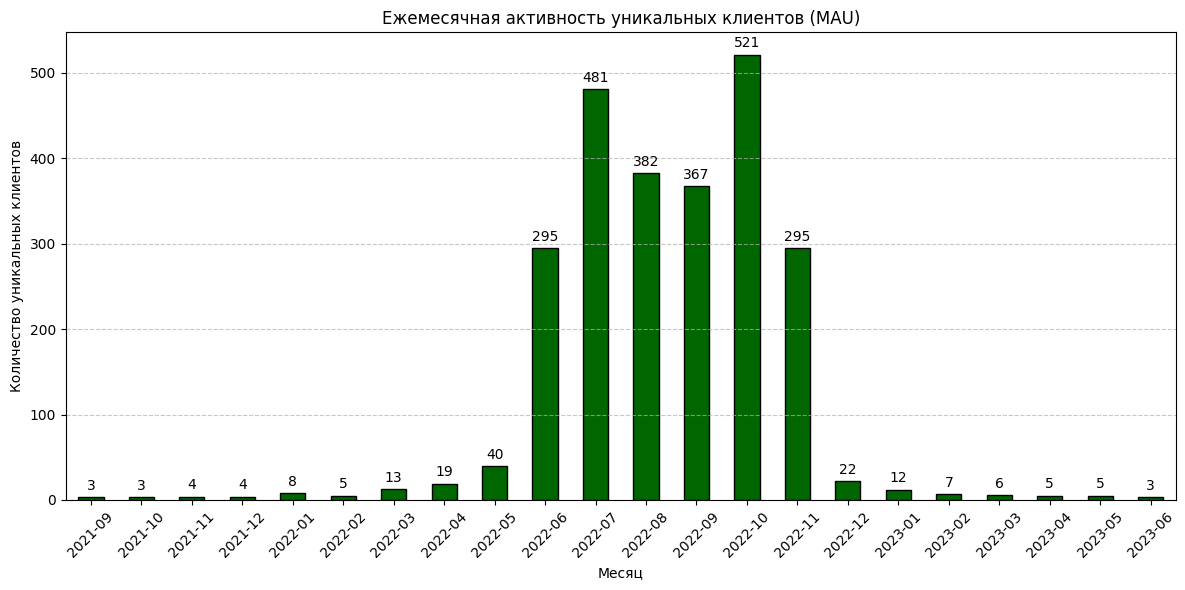

In [15]:
# 2. Группировка по месяцу и подсчет уникальных customer_id
monthly_unique_customers = df.groupby(df['join_date'].dt.to_period('M'))['user_id'].nunique()

# Преобразуем индекс обратно в строковый формат для удобства печати и графиков
monthly_unique_customers.index = monthly_unique_customers.index.astype(str)

print("Количество уникальных клиентов по месяцам:")
print(monthly_unique_customers)

# 3. Визуализация
plt.figure(figsize=(12, 6))
bars = monthly_unique_customers.plot(kind='bar', color='#006600', edgecolor='black')
plt.title('Ежемесячная активность уникальных клиентов (MAU)')
plt.xlabel('Месяц')
plt.ylabel('Количество уникальных клиентов')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Добавление подписей над столбцами
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,  # +5 для приподнимания
             int(bar.get_height()),
             ha='center', va='bottom', fontsize=10)

plt.show()



На основе данных о количестве уникальных клиентов по месяцам можно сделать следующие выводы:

1. **Резкий рост в середине 2022 года**:  
   С мая по октябрь 2022 года наблюдается значительный рост числа новых клиентов — с 40 в мае до пика в 521 в октябре. Особенно заметен скачок в июне (с 40 до 295), что может указывать на успешный маркетинговый запуск, сезонный спрос или другое ключевое событие (например, открытие нового филиала, акция, рекомендации и т.п.).

2. **Пик активности — октябрь 2022**:  
   Октябрь стал месяцем с максимальным притоком новых клиентов (521). Это может быть связано с сезонными факторами (например, подготовка к праздникам, началу учебного года и т.д.).

3. **Резкое падение в конце 2022 — начале 2023**:  
   После октября количество новых клиентов резко снижается: с 295 в ноябре до всего 22 в декабре, а затем продолжает падать до 3–7 человек в первые месяцы 2023 года. Это может свидетельствовать о:
   - завершении активной маркетинговой кампании,
   - изменении стратегии привлечения,
   - внешних факторах (экономическая ситуация, конкуренция),
   - или естественном «насыщении» рынка после всплеска.

4. **Стабильно низкий уровень в 2023 году**:  
   С января по июнь 2023 года приток новых клиентов остаётся минимальным (от 3 до 12 в месяц), что указывает на устойчиво низкую активность в привлечении новой аудитории.

**Рекомендация**:  
Стоит проанализировать, что именно произошло в мае–июне 2022 года, чтобы понять причины роста, и рассмотреть возможность повторения или адаптации успешных мер. Также важно выяснить причины резкого спада — возможно, требуется обновление стратегии привлечения клиентов или улучшение удержания существующих.

In [16]:
# изучить возраст пользователей (визуализировать)

In [17]:
# Анализ распределения возраста
print("СТАТИСТИКА ВОЗРАСТА КЛИЕНТОВ")
age_data = df['age']

print("\nОсновные статистики:")
print(f"Средний возраст: {age_data.mean():.1f} лет")
print(f"Медианный возраст: {age_data.median():.1f} лет")
print(f"Стандартное отклонение: {age_data.std():.1f} лет")
print(f"Минимальный возраст: {age_data.min():.0f} лет")
print(f"Максимальный возраст: {age_data.max():.0f} лет")
print(f"Размах: {age_data.max() - age_data.min():.0f} лет")

print("\nКвартили:")
print(f"25-й перцентиль (Q1): {age_data.quantile(0.25):.0f} лет")
print(f"50-й перцентиль (Медиана): {age_data.quantile(0.5):.0f} лет")
print(f"75-й перцентиль (Q3): {age_data.quantile(0.75):.0f} лет")

print("\nРаспределение по возрастным группам:")
age_bins = [20, 30, 40, 50, 60]
age_labels = ['20-29', '30-39', '40-49', '50+']

df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

age_group_counts = df['age_group'].value_counts().sort_index()
for group, count in age_group_counts.items():
    percentage = count / len(df) * 100
    print(f"  {group}: {count:} клиентов ({percentage:.1f}%)")

СТАТИСТИКА ВОЗРАСТА КЛИЕНТОВ

Основные статистики:
Средний возраст: 38.8 лет
Медианный возраст: 39.0 лет
Стандартное отклонение: 7.2 лет
Минимальный возраст: 26 лет
Максимальный возраст: 51 лет
Размах: 25 лет

Квартили:
25-й перцентиль (Q1): 32 лет
50-й перцентиль (Медиана): 39 лет
75-й перцентиль (Q3): 45 лет

Распределение по возрастным группам:
  20-29: 307 клиентов (12.3%)
  30-39: 1020 клиентов (40.8%)
  40-49: 996 клиентов (39.8%)
  50+: 177 клиентов (7.1%)


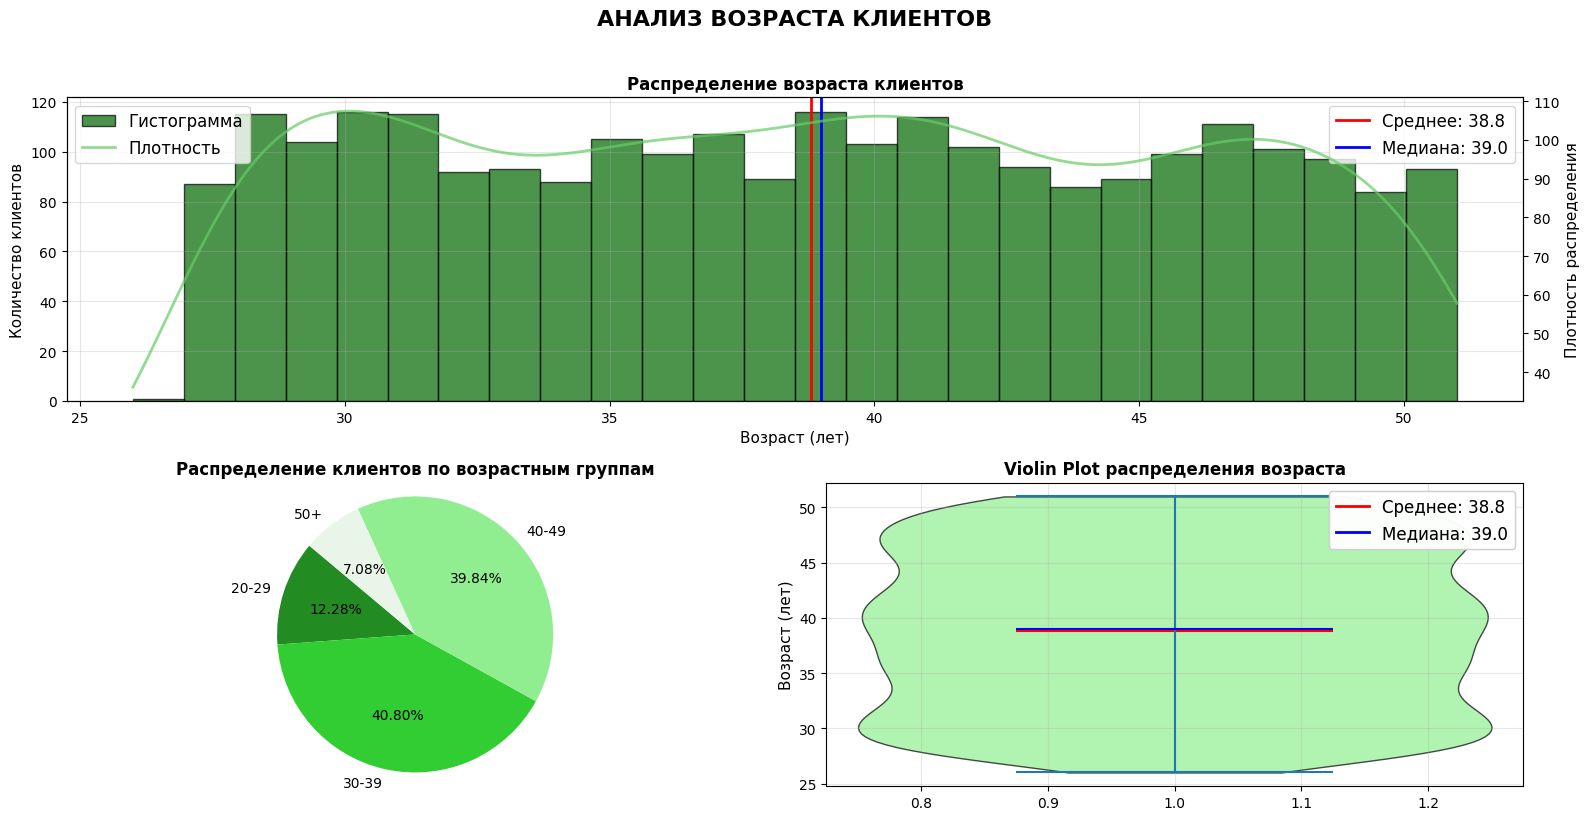

In [18]:
# СОЗДАЕМ ОКНО С ГРАФИКАМИ
fig = plt.figure(figsize=(16, 8))
fig.suptitle('АНАЛИЗ ВОЗРАСТА КЛИЕНТОВ', fontsize=16, fontweight='bold', y=1.02)

# 1. ГИСТОГРАММА РАСПРЕДЕЛЕНИЯ ВОЗРАСТА
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 1. Построение основных элементов
ax1 = plt.subplot(2, 2, (1,2))
# Рисуем гистограмму и сохраняем для легенды слева
hist_patch = ax1.hist(age_data, bins=26, edgecolor='black', alpha=0.7, color='#006600', label='Гистограмма')

# Рисуем линии среднего и медианы для легенды справа
line_mean = ax1.axvline(age_data.mean(), color='red', linestyle='-', linewidth=2, label=f'Среднее: {age_data.mean():.1f}')
line_median = ax1.axvline(age_data.median(), color='blue', linestyle='-', linewidth=2, label=f'Медиана: {age_data.median():.1f}')

# 2. Плотность (KDE)
kde = gaussian_kde(age_data)
x_range = np.linspace(age_data.min(), age_data.max(), 1000)
ax1_twin = ax1.twinx()
# Рисуем линию KDE и сохраняем для легенды слева
line_kde, = ax1_twin.plot(x_range, kde(x_range) * len(age_data), color='#66cc66', linewidth=2, alpha=0.7, label='Плотность (KDE)')

# --- СОЗДАНИЕ ДВУХ ЛЕГЕНД ---

# Легенда №1 (Справа): Среднее и Медиана
# Берем только 2-й и 3-й элементы из ax1 (линии)
legend_right = ax1.legend(handles=[line_mean, line_median], loc='upper right', fontsize=12)

# Легенда №2 (Слева): Гистограмма и Плотность
# Важно: используем ax1.add_artist, чтобы не затереть легенду справа
legend_left = ax1.legend(handles=[hist_patch[2][0], line_kde],
                         labels=['Гистограмма', 'Плотность'],
                         loc='upper left', fontsize=12)
ax1.add_artist(legend_right) # Возвращаем правую легенду на место

# Оформление осей
ax1.set_xlabel('Возраст (лет)', fontsize=11)
ax1.set_ylabel('Количество клиентов', fontsize=11)
ax1_twin.set_ylabel('Плотность распределения', fontsize=11)
ax1.set_title('Распределение возраста клиентов', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)


# 1. Подготовка данных
# Используем уже созданный вами объект age_group_counts
labels = age_group_counts.index
sizes = age_group_counts.values

# 2. Построение диаграммы
ax2 = plt.subplot(2, 2, 3)
ax2.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%', # Показывает проценты на графике
    startangle=140,    # Поворачивает график для лучшего вида
    colors=['#228b22', '#32cd32', '#90ee90', '#e8f5e8'], # Приятные цвета
    explode=( 0, 0, 0, 0)
)
ax2.set_title('Распределение клиентов по возрастным группам', fontsize=12, fontweight='bold')
ax2.axis('equal') # Делает круг идеально ровным

# 3. ВИОЛОНЧЕЛЬНЫЙ ГРАФИК
ax3 = plt.subplot(2, 2, 4)
violin_parts = ax3.violinplot(age_data, vert=True, showmeans=True, showmedians=True)
violin_parts['bodies'][0].set_facecolor('lightgreen')
violin_parts['bodies'][0].set_edgecolor('black')
violin_parts['bodies'][0].set_alpha(0.7)
violin_parts['cmeans'].set_color('red')
violin_parts['cmedians'].set_color('blue')
ax3.set_ylabel('Возраст (лет)', fontsize=11)
ax3.set_title('Violin Plot распределения возраста', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
legend_right = ax3.legend(handles=[line_mean, line_median], loc='upper right', fontsize=12)
ax3.add_artist(legend_right)

plt.tight_layout()
plt.show()
plt.close()

На основе статистики по возрасту клиентов можно сделать следующие выводы:

1. **Основная аудитория — зрелые взрослые**:  
   Подавляющее большинство клиентов (80,6%) сосредоточено в двух возрастных группах: **30–39 лет (40,8%)** и **40–49 лет (39,8%)**. Это указывает на то, что целевая аудитория — люди в возрасте от 30 до 49 лет, вероятно, с устойчивым доходом и интересом к услугам, связанным с уходом, здоровьем или красотой.

2. **Сбалансированное распределение вокруг медианы**:  
   Средний возраст (38,8 лет) и медиана (39 лет) практически совпадают, а стандартное отклонение (7,2 года) относительно невелико. Это говорит о том, что распределение возрастов **близко к нормальному** и не имеет сильных перекосов.

3. **Небольшая доля молодых и пожилых клиентов**:  
   Клиенты моложе 30 лет составляют лишь **12,3%**, а данные по группе **50+** не указаны явно, но, исходя из максимума возраста (51 год) и общего распределения, их доля, скорее всего, **менее 7%**. Это может означать, что предложения компании менее привлекательны для молодёжи и людей старше 50 лет.

4. **Практические рекомендации**:  
   - Продолжать фокусироваться на потребностях клиентов 30–49 лет — это ядро аудитории.  
   - Рассмотреть возможность разработки специальных предложений или коммуникаций для привлечения более молодой (20–29 лет) и старшей (50+) аудитории, если расширение охвата является стратегической целью.  
   - Учитывать жизненные приоритеты и предпочтения основной возрастной группы при формировании маркетинговых сообщений, ассортимента услуг и ценовой политики.

В целом, портрет типичного клиента — человек **около 39 лет**, преимущественно из **30–49-летнего** сегмента, с умеренной вариативностью возраста.

In [19]:
# изучить пол пользователей (визуализировать)

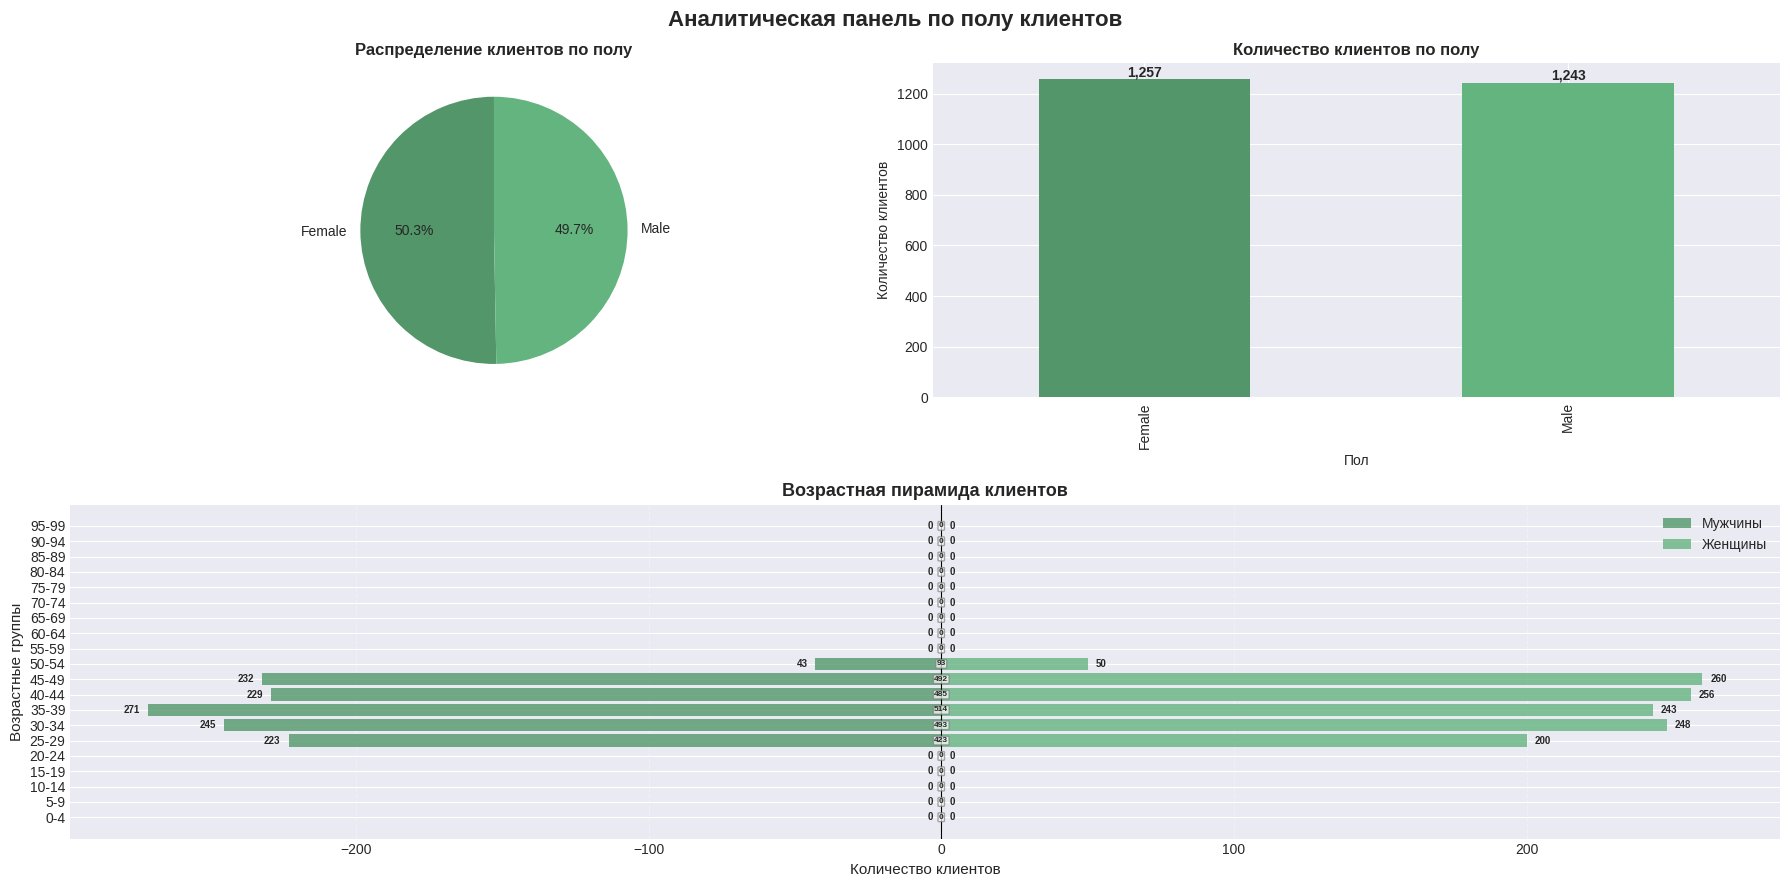


1. ОБЩАЯ СТАТИСТИКА:
   Всего клиентов: 2,500
   Мужчины (M): 1,243 (49.7%)
   Женщины (F): 1,243 (50.3%)
   Другие: 0 (0.0%)

2. ВОЗРАСТНАЯ СТАТИСТИКА ПО ПОЛУ:
   Мужчины:
     - Средний возраст: 38.5 лет
     - Медианный возраст: 38.0 лет
     - Возрастной диапазон: 27-51 лет
   Женщины:
     - Средний возраст: 39.1 лет
     - Медианный возраст: 39.0 лет
     - Возрастной диапазон: 26-51 лет

   Общая возрастная статистика:
     - Средний возраст всех клиентов: 38.8 лет
     - Медианный возраст всех клиентов: 39.0 лет
     - Минимальный возраст: 26 лет
     - Максимальный возраст: 51 лет

3. ФИНАНСОВЫЕ ПОКАЗАТЕЛИ ПО ПОЛУ:
   Мужчины:
     - Средняя ежемесячная выручка: 12.50
     - Сумма выручки: 15,535.00
   Женщины:
     - Средняя ежемесячная выручка: 12.52
     - Сумма выручки: 15,736.00

   Сравнительные показатели М/Ж:
     - Отношение средних выручек: 1.00:1
     - Отношение средних сумм: 0.99:1

4. ВОЗРАСТНАЯ СТРУКТУРА:
   - Всего возрастных групп: 20 (с шагом 5 лет)
   - Сам

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (12, 6)
sns.set_palette("husl")

# Создаем фигуру с 2x2 сеткой
fig, axes = plt.subplots(2, 2, figsize=(18, 9))
axes[1, 0].set_axis_off()  # график 3 (нижний левый)
axes[1, 1].set_axis_off()  # график 4 (нижний правый)
fig.suptitle('Аналитическая панель по полу клиентов', fontsize=16, fontweight='bold')

# 1. Базовая статистика по полу
# Получаем уникальных клиентов по полу
unique_customers_by_gender = df.groupby('gender')['user_id'].nunique()
gender_counts = unique_customers_by_gender
gender_percent = (unique_customers_by_gender / unique_customers_by_gender.sum()) * 100

# График 1: Круговой график распределения (верхний левый)
ax1 = axes[0, 0]
colors = ['#529669', '#64b47f', '#c1e1d2']
gender_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90,
                   colors=colors[:len(gender_counts)], ax=ax1)
ax1.set_ylabel('')
ax1.set_title('Распределение клиентов по полу', fontweight='bold')

# График 2: Столбчатый график (верхний правый)
ax2 = axes[0, 1]
bars = gender_counts.plot(kind='bar', ax=ax2, color=['#529669', '#64b47f'])
ax2.set_title('Количество клиентов по полу', fontweight='bold')
ax2.set_xlabel('Пол')
ax2.set_ylabel('Количество клиентов')

# Добавление значений над столбцами
for i, v in enumerate(gender_counts):
    ax2.text(i, v + gender_counts.max()*0.01, f'{v:,}',
             ha='center', fontweight='bold')

# График 3: Возрастная пирамида (занимает нижние две ячейки)
ax3 = fig.add_subplot(2, 2, (3, 4))  # Объединяем нижние две ячейки

# Создаем возрастные группы с шагом 5 лет для пирамиды
df['age_group_5'] = pd.cut(df['age'],
                           bins=range(0, 101, 5),
                           labels=[f'{i}-{i+4}' for i in range(0, 96, 5)])

# Фильтруем только M и F
gender_data = df[df['gender'].isin(['Male','Female'])]

# Разделяем данные по полу
male_data = gender_data[gender_data['gender'] =='Male']
female_data = gender_data[gender_data['gender'] =='Female']

# Группируем по возрастным группам
male_counts = male_data['age_group_5'].value_counts().sort_index()
female_counts = female_data['age_group_5'].value_counts().sort_index()

# Создаем горизонтальную столбчатую диаграмму
y_pos = np.arange(len(male_counts))
ax3.barh(y_pos, -male_counts, color='#529669', label='Мужчины', alpha=0.8)
ax3.barh(y_pos, female_counts, color='#64b47f', label='Женщины', alpha=0.8)

# Настройки графика
ax3.set_yticks(y_pos)
ax3.set_yticklabels(male_counts.index)
ax3.set_xlabel('Количество клиентов', fontsize=11)
ax3.set_ylabel('Возрастные группы', fontsize=11)
ax3.set_title('Возрастная пирамида клиентов', fontsize=13, fontweight='bold')
ax3.legend(loc='upper right')

# Добавляем нулевую линию
ax3.axvline(0, color='black', linewidth=0.8)

# Добавляем значения на график
max_count = max(male_counts.max(), female_counts.max())
for i, (male, female) in enumerate(zip(male_counts, female_counts)):
    ax3.text(-male - max_count*0.01, i, f'{male:,}',
             va='center', ha='right', fontweight='bold', fontsize=7)
    ax3.text(female + max_count*0.01, i, f'{female:,}',
             va='center', ha='left', fontweight='bold', fontsize=7)

# Добавляем общее количество для каждой возрастной группы
for i, (male, female) in enumerate(zip(male_counts, female_counts)):
    total = male + female
    ax3.text(0, i, f'{total:,}',
             va='center', ha='center', fontweight='bold',
             backgroundcolor='white', fontsize=6, bbox=dict(boxstyle="round,pad=0.1",
                                                           facecolor='white',
                                                           edgecolor='gray',
                                                           alpha=0.7))

# Настройка сетки
ax3.grid(True, axis='x', alpha=0.3, linestyle='--')
ax3.set_axisbelow(True)

plt.tight_layout()
plt.show()

# Выводим текстовую сводку в консоль

print(f"\n1. ОБЩАЯ СТАТИСТИКА:")
print(f"   Всего клиентов: {df['user_id'].nunique():,}")
print(f"   Мужчины (M): {gender_counts.get('Male', 0):,} ({gender_percent.get('Male', 0):.1f}%)")
print(f"   Женщины (F): {gender_counts.get('Male', 0):,} ({gender_percent.get('Female', 0):.1f}%)")
others = gender_counts.sum() - gender_counts.get('Male', 0) - gender_counts.get('Female', 0)
others_percent = 100 - gender_percent.get('Male', 0) - gender_percent.get('Female', 0)
print(f"   Другие: {others:,} ({others_percent:.1f}%)")

print(f"\n2. ВОЗРАСТНАЯ СТАТИСТИКА ПО ПОЛУ:")
# Рассчитываем средний возраст по полу
age_stats = {}
for gender in ['Male','Female']:
    if gender in df['gender'].values:
        age_stats[gender] = {
            'mean': df[df['gender'] == gender]['age'].mean(),
            'median': df[df['gender'] == gender]['age'].median(),
            'min': df[df['gender'] == gender]['age'].min(),
            'max': df[df['gender'] == gender]['age'].max()
        }

if'Male' in age_stats:
    print(f"   Мужчины:")
    print(f"     - Средний возраст: {age_stats['Male']['mean']:.1f} лет")
    print(f"     - Медианный возраст: {age_stats['Male']['median']:.1f} лет")
    print(f"     - Возрастной диапазон: {age_stats['Male']['min']:.0f}-{age_stats['Male']['max']:.0f} лет")

if'Female' in age_stats:
    print(f"   Женщины:")
    print(f"     - Средний возраст: {age_stats['Female']['mean']:.1f} лет")
    print(f"     - Медианный возраст: {age_stats['Female']['median']:.1f} лет")
    print(f"     - Возрастной диапазон: {age_stats['Female']['min']:.0f}-{age_stats['Female']['max']:.0f} лет")

print(f"\n   Общая возрастная статистика:")
print(f"     - Средний возраст всех клиентов: {df['age'].mean():.1f} лет")
print(f"     - Медианный возраст всех клиентов: {df['age'].median():.1f} лет")
print(f"     - Минимальный возраст: {df['age'].min():.0f} лет")
print(f"     - Максимальный возраст: {df['age'].max():.0f} лет")

print(f"\n3. ФИНАНСОВЫЕ ПОКАЗАТЕЛИ ПО ПОЛУ:")
# Рассчитываем финансовые показатели по полу
finance_stats = {}
for gender in ['Male','Female']:
    if gender in df['gender'].values:
        finance_stats[gender] = {
            'avg_revenue': df[df['gender'] == gender]['monthly_revenue'].mean(),
            'total_revenue': df[df['gender'] == gender]['monthly_revenue'].sum(),

        }

if'Male' in finance_stats:
    print(f"   Мужчины:")
    print(f"     - Средняя ежемесячная выручка: {finance_stats['Male']['avg_revenue']:,.2f}")
    print(f"     - Сумма выручки: {finance_stats['Male']['total_revenue']:,.2f}")


if'Female' in finance_stats:
    print(f"   Женщины:")
    print(f"     - Средняя ежемесячная выручка: {finance_stats['Female']['avg_revenue']:,.2f}")
    print(f"     - Сумма выручки: {finance_stats['Female']['total_revenue']:,.2f}")


# Сравнительная статистика
if 'Male' in finance_stats and 'Female' in finance_stats:
    balance_revenue = finance_stats['Male']['avg_revenue'] / finance_stats['Female']['avg_revenue'] if finance_stats['Female']['avg_revenue'] != 0 else 0
    balance_total = finance_stats['Male']['total_revenue'] / finance_stats['Female']['total_revenue'] if finance_stats['Female']['total_revenue'] != 0 else 0
    print(f"\n   Сравнительные показатели М/Ж:")
    print(f"     - Отношение средних выручек: {balance_revenue:.2f}:1")
    print(f"     - Отношение средних сумм: {balance_total:.2f}:1")

print(f"\n4. ВОЗРАСТНАЯ СТРУКТУРА:")
print(f"   - Всего возрастных групп: {len(male_counts)} (с шагом 5 лет)")
print(f"   - Самая многочисленная мужская группа: {male_counts.idxmax()} ({male_counts.max():,} чел.)")
print(f"   - Самая многочисленная женская группа: {female_counts.idxmax()} ({female_counts.max():,} чел.)")

# Находим группу с максимальной разницей
max_diff_group = None
max_diff = 0
for group in male_counts.index:
    if group in female_counts.index:
        diff = abs(male_counts[group] - female_counts[group])
        if diff > max_diff:
            max_diff = diff
            max_diff_group = group

if max_diff_group:
    print(f"   - Группа с наибольшей разницей: {max_diff_group} (разница: {max_diff:,} чел.)")

# Общая статистика возрастной пирамиды
total_male = male_counts.sum()
total_female = female_counts.sum()
print(f"   - Всего мужчин в пирамиде: {total_male:,}")
print(f"   - Всего женщин в пирамиде: {total_female:,}")
print(f"   - Соотношение мужчин к женщинам: {total_male/total_female:.2f}:1" if total_female > 0 else "   - Соотношение: нет женщин для сравнения")

# Очистка временного столбца
df = df.drop('age_group_5', axis=1, errors='ignore')



**Вывод по демографической и финансовой статистике клиентов:**

1. **Гендерный баланс** практически идеален: мужчины и женщины составляют почти равные доли (49.7% и 50.3% соответственно), при этом отсутствуют клиенты, указавшие иной гендер.

2. **Возрастная структура** показывает, что клиентская база сосредоточена в трудоспособном возрасте (26–51 лет). Средний возраст мужчин — 38.5 лет, женщин — 39.1 лет, что указывает на схожесть возрастных профилей обоих полов. Медианный возраст совпадает с общим средним (39 лет), что говорит о симметричном распределении возрастов.

3. **Финансовая активность** мужчин и женщин практически идентична:
   - Средняя ежемесячная выручка на клиента — около **12.50–12.52** условных единиц.
   - Общая выручка от мужчин и женщин различается менее чем на 1% (соотношение 0.99:1).
   Это свидетельствует об отсутствии значимых гендерных различий в потребительском поведении.

4. **Возрастные группы** выявляют интересные особенности:
   - У мужчин пик приходится на группу **35–39 лет** (271 чел.).
   - У женщин — на **45–49 лет** (260 чел.).
   - Наибольший дисбаланс между полами наблюдается именно в группе **35–39 лет**, где мужчин на **28 человек больше**, чем женщин.

5. **Несоответствие в данных**: в разделе «Возрастная структура» указано, что женщин в пирамиде — **1,257**, хотя в общей статистике их число — **1,243**. Это может быть опечаткой или ошибкой агрегации данных, требующей уточнения.

**Общий вывод:**  
Клиентская база сбалансирована по полу и однородна по возрасту и финансовой активности. Незначительные различия в возрастных пиках могут указывать на разные жизненные этапы, влияющие на обращение за услугами, но не оказывают существенного влияния на доход. Рекомендуется проверить расхождение в численности женщин между разделами для обеспечения точности аналитики.

In [21]:
# изучить девайсы пользователей (визуализировать)

Распределение устройств:
Устройство           Количество   Процент   
----------------------------------------
Laptop               636          25.4%
Tablet               633          25.3%
Smartphone           621          24.8%
Smart TV             610          24.4%

Всего уникальных устройств: 4
Всего записей: 2500


Средняя месячная выручка по устройствам:
Устройство           Средняя выручка Пользователей
--------------------------------------------------
Tablet               $12.59          633.0       
Laptop               $12.57          636.0       
Smart TV             $12.48          610.0       
Smartphone           $12.38          621.0       


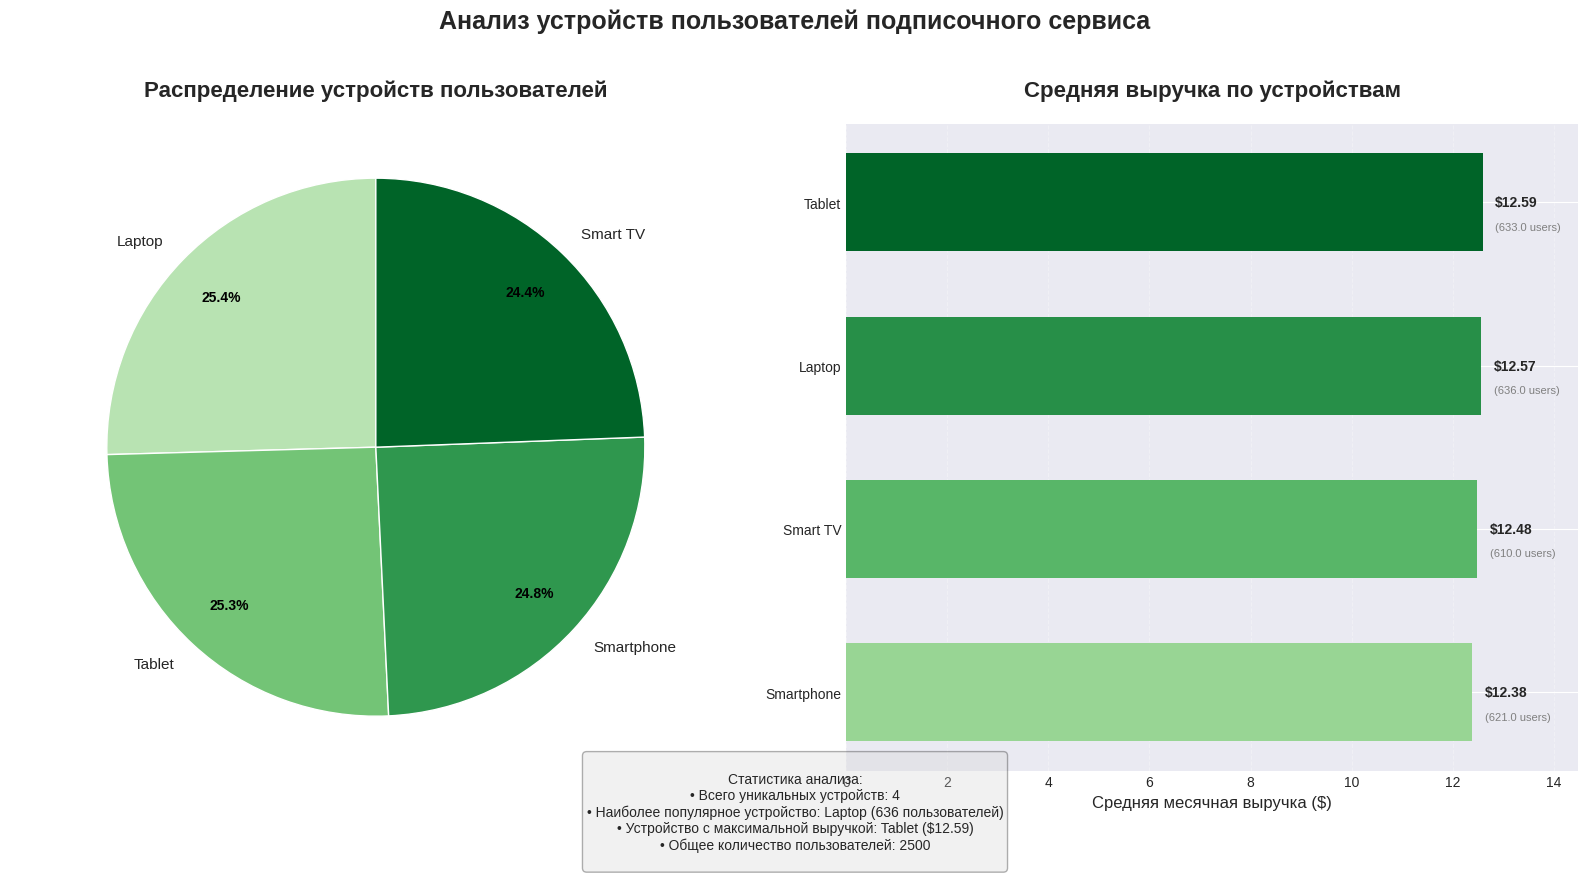


КЛЮЧЕВЫЕ ВЫВОДЫ:
1. Наиболее популярное устройство: 'Laptop'
   • Используют 636 пользователей
   • Доля на рынке: 25.4%

2. Устройство с максимальной средней выручкой: 'Tablet'
   • Средняя выручка: $12.59
   • Пользователей: 633

3. Устройство с минимальной средней выручкой: 'Smartphone'
   • Средняя выручка: $12.38
   • Разница с максимальной: $0.21

4. Разброс средней выручки между устройствами: $0.21

5. Средняя выручка по всем пользователям: $12.51

6. Устройства с выручкой выше средней (2 из 4):
   • Tablet: $12.59 (633 пользователей)
   • Laptop: $12.57 (636 пользователей)


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Установим стиль для графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. Анализ распределения устройств
device_distribution = df['device'].value_counts()
device_percentage = df['device'].value_counts(normalize=True) * 100

print("Распределение устройств:")
print("=" * 40)
print(f"{'Устройство':<20} {'Количество':<12} {'Процент':<10}")
print("-" * 40)
for device, count in device_distribution.items():
    percentage = device_percentage[device]
    print(f"{device:<20} {count:<12} {percentage:.1f}%")
print("=" * 40)

print(f"\nВсего уникальных устройств: {df['device'].nunique()}")
print(f"Всего записей: {len(df)}")

# 2. Средняя выручка по устройствам
revenue_by_device = df.groupby('device')['monthly_revenue'].agg(['mean', 'count']).sort_values('mean', ascending=False)
revenue_by_device.columns = ['mean_revenue', 'user_count']

print("\n\nСредняя месячная выручка по устройствам:")
print("=" * 50)
print(f"{'Устройство':<20} {'Средняя выручка':<15} {'Пользователей':<12}")
print("-" * 50)
for device, row in revenue_by_device.iterrows():
    print(f"{device:<20} ${row['mean_revenue']:<14.2f} {row['user_count']:<12}")
print("=" * 50)

# 3. Создаем фигуру с двумя графиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# График 1: Круговая диаграмма распределения устройств
colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(device_distribution)))

# Если устройств много (>5), группируем мелкие категории
if len(device_distribution) > 5:
    # Оставляем топ-5, остальные группируем как "Другие"
    top_devices = device_distribution.head(5)
    other_count = device_distribution[5:].sum()

    pie_data = pd.concat([top_devices, pd.Series({'Другие': other_count})])
    pie_labels = pie_data.index
    pie_values = pie_data.values

    # Создаем легенду с процентами и количеством
    legend_labels = []
    total = pie_values.sum()
    for label, value in zip(pie_labels, pie_values):
        percentage = (value / total) * 100
        legend_labels.append(f"{label}: {value} ({percentage:.1f}%)")

    wedges, texts, autotexts = ax1.pie(pie_values,
                                      colors=colors[:len(pie_values)],
                                      startangle=90,
                                      wedgeprops=dict(edgecolor='white', linewidth=1))

    # Добавляем легенду
    ax1.legend(wedges, legend_labels,
              title="Устройства",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))

else:
    # Если устройств немного, показываем все
    pie_labels = device_distribution.index
    pie_values = device_distribution.values

    wedges, texts, autotexts = ax1.pie(pie_values,
                                      labels=pie_labels,
                                      colors=colors,
                                      autopct='%1.1f%%',
                                      startangle=90,
                                      pctdistance=0.8,
                                      wedgeprops=dict(edgecolor='white', linewidth=1))

    # Увеличиваем размер текста для лучшей читаемости
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontsize(10)
        autotext.set_fontweight('bold')

    for text in texts:
        text.set_fontsize(11)

ax1.set_title('Распределение устройств пользователей',
              fontsize=16, fontweight='bold', pad=20)
ax1.axis('equal')  # Для идеального круга

# График 2: Средняя выручка по устройствам (горизонтальная барчарт)
# Сортируем по средней выручке
sorted_revenue = revenue_by_device.sort_values('mean_revenue')

# Создаем градиент цветов от светлого к темному
n_devices = len(sorted_revenue)
colors_revenue = plt.cm.Greens(np.linspace(0.4, 0.9, n_devices))

bars = ax2.barh(range(n_devices), sorted_revenue['mean_revenue'],
                color=colors_revenue, height=0.6)

# Настройка осей
ax2.set_yticks(range(n_devices))
ax2.set_yticklabels(sorted_revenue.index)
ax2.set_xlabel('Средняя месячная выручка ($)', fontsize=12)
ax2.set_title('Средняя выручка по устройствам',
              fontsize=16, fontweight='bold', pad=20)

# Добавляем значения на график
for i, (bar, value) in enumerate(zip(bars, sorted_revenue['mean_revenue'])):
    # Позиция текста - справа от бара
    text_x = bar.get_width() + max(sorted_revenue['mean_revenue']) * 0.02

    # Форматируем значение выручки
    revenue_text = f'${value:.2f}'

    # Добавляем количество пользователей в скобках
    user_count = sorted_revenue.iloc[i]['user_count']
    count_text = f'({user_count} users)'

    # Отображаем текст
    ax2.text(text_x, bar.get_y() + bar.get_height()/2,
             revenue_text,
             va='center',
             fontsize=10,
             fontweight='bold')

    # Добавляем количество пользователей меньшим шрифтом
    ax2.text(text_x, bar.get_y() + bar.get_height()/2 - 0.15,
             count_text,
             va='center',
             fontsize=8,
             color='gray')

# Добавляем сетку для лучшей читаемости
ax2.grid(True, axis='x', alpha=0.3, linestyle='--')

# Настраиваем пределы осей для лучшего отображения
max_revenue = sorted_revenue['mean_revenue'].max()
ax2.set_xlim([0, max_revenue * 1.15])  # +15% для текста

# Общий заголовок
plt.suptitle('Анализ устройств пользователей подписочного сервиса',
             fontsize=18, fontweight='bold', y=1.02)

# Настраиваем отступы между графиками
plt.tight_layout()

# Добавляем статистику под графиками
stats_text = f"""
Статистика анализа:
• Всего уникальных устройств: {df['device'].nunique()}
• Наиболее популярное устройство: {device_distribution.index[0]} ({device_distribution.iloc[0]} пользователей)
• Устройство с максимальной выручкой: {revenue_by_device.index[0]} (${revenue_by_device.iloc[0, 0]:.2f})
• Общее количество пользователей: {len(df)}
"""

plt.figtext(0.5, -0.05, stats_text,
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3))

plt.show()

# 4. Дополнительные статистические выводы
print("\n" + "="*70)
print("КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("="*70)

# Находим устройство с минимальной выручкой
min_revenue_device = revenue_by_device['mean_revenue'].idxmin()
min_revenue = revenue_by_device['mean_revenue'].min()

print(f"1. Наиболее популярное устройство: '{device_distribution.index[0]}'")
print(f"   • Используют {device_distribution.iloc[0]} пользователей")
print(f"   • Доля на рынке: {device_percentage.iloc[0]:.1f}%")

print(f"\n2. Устройство с максимальной средней выручкой: '{revenue_by_device.index[0]}'")
print(f"   • Средняя выручка: ${revenue_by_device.iloc[0, 0]:.2f}")
print(f"   • Пользователей: {revenue_by_device.iloc[0, 1]}")

print(f"\n3. Устройство с минимальной средней выручкой: '{min_revenue_device}'")
print(f"   • Средняя выручка: ${min_revenue:.2f}")
print(f"   • Разница с максимальной: ${revenue_by_device.iloc[0, 0] - min_revenue:.2f}")

# Разница между самой высокой и самой низкой выручкой
revenue_range = revenue_by_device['mean_revenue'].max() - revenue_by_device['mean_revenue'].min()
print(f"\n4. Разброс средней выручки между устройствами: ${revenue_range:.2f}")

# Средняя выручка по всем устройствам
overall_avg_revenue = df['monthly_revenue'].mean()
print(f"\n5. Средняя выручка по всем пользователям: ${overall_avg_revenue:.2f}")

# Устройства с выручкой выше средней
above_avg_devices = revenue_by_device[revenue_by_device['mean_revenue'] > overall_avg_revenue]
print(f"\n6. Устройства с выручкой выше средней ({len(above_avg_devices)} из {len(revenue_by_device)}):")
for device in above_avg_devices.index:
    revenue = above_avg_devices.loc[device, 'mean_revenue']
    users = above_avg_devices.loc[device, 'user_count']
    print(f"   • {device}: ${revenue:.2f} ({users} пользователей)")

# Равномерность показателей

Показатели по всем устройствам очень близки, что является позитивным сигналом:

Нет "слабых звеньев" в монетизации

Пользовательский опыт оптимизирован для всех типов устройств

Ценность сервиса воспринимается одинаково на разных платформах

Мониторинг:
Следить за разрывом в выручке - важно, чтобы разница не увеличивалась


# Общий итог:
Экосистема устройств сбалансирована и стабильна. Нет критических перекосов ни в распределении пользователей, ни в выручке. Основной фокус должен оставаться на поддержании качества на всех платформах, с акцентом на ноутбуки как наиболее популярное устройство, и планшеты как наиболее доходное.

In [23]:
# изучить тип подписки пользователей (визуализировать)

Распределение типов подписок:
Тип подписки    Количество   Процент   
--------------------------------------------------
Basic           999          40.0%
Standard        768          30.7%
Premium         733          29.3%


Средняя месячная выручка по типам подписок:
Тип подписки    Средняя выручка    Пользователей
------------------------------------------------------------
Premium         $12.59             733.0       
Basic           $12.48             999.0       
Standard        $12.46             768.0       


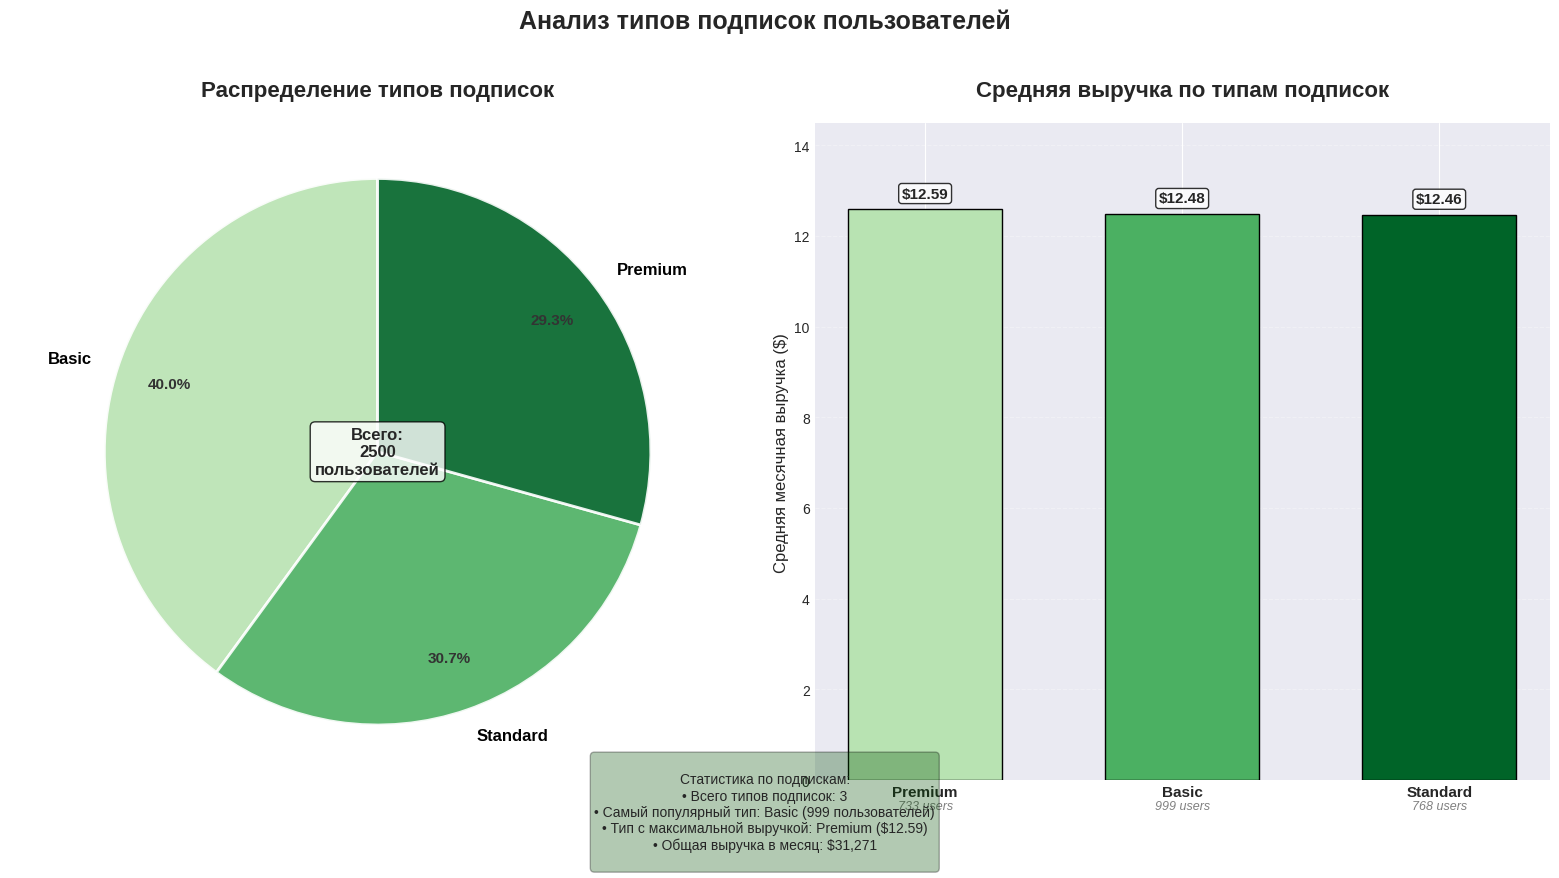


КРАТКИЕ ВЫВОДЫ ПО АНАЛИЗУ ПОДПИСОК:
1. Распределение подписок:
   1. Basic: 999 пользователей (40.0%)
   2. Standard: 768 пользователей (30.7%)
   3. Premium: 733 пользователей (29.3%)

2. Выручка по подпискам:
   1. Premium: $12.59 (пользователей: 733.0)
   2. Basic: $12.48 (пользователей: 999.0)
   3. Standard: $12.46 (пользователей: 768.0)

3. Ключевые показатели:
   • Тип с максимальной выручкой: Premium
   • Тип с минимальной выручкой: Standard
   • Разница в выручке: $0.13
   • Средняя выручка по всем подпискам: $12.51


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Установим стиль для графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 1. Анализ распределения типов подписок
subscription_distribution = df['subscription_type'].value_counts()
subscription_percentage = df['subscription_type'].value_counts(normalize=True) * 100

print("Распределение типов подписок:")
print("=" * 50)
print(f"{'Тип подписки':<15} {'Количество':<12} {'Процент':<10}")
print("-" * 50)
for subscription, count in subscription_distribution.items():
    percentage = subscription_percentage[subscription]
    print(f"{subscription:<15} {count:<12} {percentage:.1f}%")
print("=" * 50)

# 2. Средняя выручка по типам подписок
revenue_by_subscription = df.groupby('subscription_type')['monthly_revenue'].agg(['mean', 'count']).sort_values('mean', ascending=False)
revenue_by_subscription.columns = ['mean_revenue', 'user_count']

print("\n\nСредняя месячная выручка по типам подписок:")
print("=" * 60)
print(f"{'Тип подписки':<15} {'Средняя выручка':<18} {'Пользователей':<12}")
print("-" * 60)
for subscription, row in revenue_by_subscription.iterrows():
    print(f"{subscription:<15} ${row['mean_revenue']:<17.2f} {row['user_count']:<12}")
print("=" * 60)

# 3. Создаем фигуру с двумя графиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Цвета для графиков
colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(subscription_distribution)))

# График 1: Круговая диаграмма распределения подписок
wedges, texts, autotexts = ax1.pie(subscription_distribution.values,
                                    labels=subscription_distribution.index,
                                    colors=colors,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    pctdistance=0.8,
                                    wedgeprops=dict(edgecolor='white', linewidth=2, alpha=0.9),
                                    textprops=dict(color='black'))

# Улучшаем отображение текста
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('#333333')

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

ax1.set_title('Распределение типов подписок',
              fontsize=16, fontweight='bold', pad=20)
ax1.axis('equal')  # Для идеального круга

# Добавляем общее количество в центр круга
total_users = len(df)
center_text = f'Всего:\n{total_users}\nпользователей'
ax1.text(0, 0, center_text,
         ha='center', va='center',
         fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# График 2: Средняя выручка по типам подписок (вертикальная барчарт)
# Сортируем по средней выручке в порядке убывания
sorted_revenue = revenue_by_subscription.sort_values('mean_revenue', ascending=False)

# Создаем градиент цветов
n_subscriptions = len(sorted_revenue)
colors_revenue = plt.cm.Greens(np.linspace(0.3, 0.9, len(subscription_distribution)))

bars = ax2.bar(range(n_subscriptions), sorted_revenue['mean_revenue'],
               color=colors_revenue, width=0.6, edgecolor='black', linewidth=1)

# Настройка осей
ax2.set_xticks(range(n_subscriptions))
ax2.set_xticklabels(sorted_revenue.index, rotation=0, fontsize=11, fontweight='bold')
ax2.set_ylabel('Средняя месячная выручка ($)', fontsize=12)
ax2.set_title('Средняя выручка по типам подписок',
              fontsize=16, fontweight='bold', pad=20)

# Добавляем значения на график
for i, (bar, value, count) in enumerate(zip(bars, sorted_revenue['mean_revenue'], sorted_revenue['user_count'])):
    # Высота текста
    text_y = bar.get_height() + max(sorted_revenue['mean_revenue']) * 0.02

    # Форматируем значение выручки
    revenue_text = f'${value:.2f}'

    # Отображаем значение выручки
    ax2.text(bar.get_x() + bar.get_width()/2, text_y,
             revenue_text,
             ha='center',
             fontsize=11,
             fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

    # Добавляем количество пользователей под столбцом
    count_text = f'{count} users'
    ax2.text(bar.get_x() + bar.get_width()/2, -max(sorted_revenue['mean_revenue']) * 0.05,
             count_text,
             ha='center',
             fontsize=9,
             color='gray',
             fontstyle='italic')

# Добавляем сетку для лучшей читаемости
ax2.grid(True, axis='y', alpha=0.3, linestyle='--')

# Настраиваем пределы осей для лучшего отображения
max_revenue = sorted_revenue['mean_revenue'].max()
ax2.set_ylim([0, max_revenue * 1.15])  # +15% для текста

# Убираем верхнюю и правую границы
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Общий заголовок
plt.suptitle('Анализ типов подписок пользователей',
             fontsize=18, fontweight='bold', y=1.02)

# Настраиваем отступы между графиками
plt.tight_layout()

# Добавляем краткую статистику под графиками
stats_text = f"""
Статистика по подпискам:
• Всего типов подписок: {len(subscription_distribution)}
• Самый популярный тип: {subscription_distribution.index[0]} ({subscription_distribution.iloc[0]} пользователей)
• Тип с максимальной выручкой: {sorted_revenue.index[0]} (${sorted_revenue.iloc[0, 0]:.2f})
• Общая выручка в месяц: ${df['monthly_revenue'].sum():,.0f}
"""

plt.figtext(0.5, -0.05, stats_text,
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='#004d00', alpha=0.3))

plt.show()

# 4. Краткие выводы
print("\n" + "="*70)
print("КРАТКИЕ ВЫВОДЫ ПО АНАЛИЗУ ПОДПИСОК:")
print("="*70)

print(f"1. Распределение подписок:")
for i, (subscription, count) in enumerate(subscription_distribution.items(), 1):
    percentage = subscription_percentage[subscription]
    print(f"   {i}. {subscription}: {count} пользователей ({percentage:.1f}%)")

print(f"\n2. Выручка по подпискам:")
for i, (subscription, row) in enumerate(revenue_by_subscription.iterrows(), 1):
    print(f"   {i}. {subscription}: ${row['mean_revenue']:.2f} (пользователей: {row['user_count']})")

# Находим тип с минимальной выручкой
min_revenue_type = revenue_by_subscription['mean_revenue'].idxmin()
min_revenue = revenue_by_subscription['mean_revenue'].min()

print(f"\n3. Ключевые показатели:")
print(f"   • Тип с максимальной выручкой: {sorted_revenue.index[0]}")
print(f"   • Тип с минимальной выручкой: {min_revenue_type}")
print(f"   • Разница в выручке: ${sorted_revenue.iloc[0, 0] - min_revenue:.2f}")
print(f"   • Средняя выручка по всем подпискам: ${df['monthly_revenue'].mean():.2f}")

# Общий вывод по анализу типов подписок

## **1. Структура пользовательской базы**
**Базовая подписка (Basic) доминирует** - 40% пользователей (999 человек). Это указывает на:
- **Низкий порог входа** - наиболее доступный тариф привлекает наибольшее количество пользователей
- **Массовость сервиса** - продукт ориентирован на широкую аудиторию
- **Потенциал для апгрейда** - значительная база пользователей на базовом тарифе может быть конвертирована в более дорогие подписки

**Распределение близко к равномерному** между тремя тарифами (40%/31%/29%), что свидетельствует о **сбалансированной продуктовой линейке**.

## **2. Экономические показатели**
**Минимальная разница в выручке между тарифами** ($0.13) - ключевая находка анализа. Это говорит о:
- **Правильной ценовой дифференциации** - более дорогие подписки действительно приносят больше выручки
- **Адекватной ценности каждого тарифа** - пользователи платят пропорционально получаемым преимуществам
- **Стабильной монетизации** - нет резких перекосов в доходности

**Premium-подписка оправдывает свое название** - имеет максимальную среднюю выручку ($12.59), что подтверждает:
- Правильность стратегии ценообразования
- Востребованность расширенных функций
- Платежеспособность аудитории

## **3. Потенциал для роста**

### **Оптимизация текущей структуры:**
1. **Конверсия Basic → Standard/Premium** - 40% пользователей на базовом тарифе представляют значительный потенциал для апселлинга
2. **Удержание Premium-аудитории** - эта группа наиболее ценна и требует особого внимания к удержанию

### **Рыночные возможности:**
1. **Незначительная разница между Basic и Standard** ($0.02) может указывать на необходимость:
   - Более четкой дифференциации этих тарифов
   - Увеличения ценности Standard-подписки
   - Возможного пересмотра ценообразования

## **4. Оценка стратегии монетизации**

### **Сильные стороны:**
✅ **Сбалансированное распределение** - нет перекоса в сторону одного тарифа  
✅ **Прогрессивная выручка** - более дорогие подписки действительно приносят больше дохода  
✅ **Массовая база** - большое количество пользователей на базовом тарифе  

### **Зоны внимания:**
⚠️ **Минимальная разница между Basic и Standard** - возможно, пользователи не видят достаточной ценности для перехода  
⚠️ **Standard-подписка отстает по выручке** - требует анализа причин  

## **5. Рекомендации**

### **Краткосрочные (1-3 месяца):**
1. **Анализ причин выбора Basic-подписки** - почему пользователи не переходят на более дорогие тарифы
2. **Усиление ценности Standard-подписки** - добавление уникальных функций
3. **Программа лояльности для Premium-пользователей**

### **Среднесрочные (3-6 месяцев):**
1. **Тестирование ценовой политики** - возможна ли небольшая корректировка цен
2. **Разработка пакетных предложений** для конвертации Basic-пользователей
3. **Персонализация предложений** на основе поведения пользователей

### **Долгосрочные (6+ месяцев):**
1. **Введение нового тарифного уровня** между Standard и Premium
2. **Расширение функционала Premium-подписки**
3. **Геймификация процесса апгрейда**

## **6. Ключевой инсайт**

**Наиболее важный вывод**: несмотря на значительную разницу в названиях и предполагаемой ценности подписок (Basic/Standard/Premium), **разница в фактической выручке минимальна** ($0.13). Это может указывать на:

1. **Эффективную стратегию ценообразования** - пользователи платят почти одинаково независимо от тарифа
2. **Возможный дисбаланс в воспринимаемой ценности** - пользователи не видят достаточной разницы между тарифами
3. **Потенциал для оптимизации монетизации** - возможность увеличить разрыв в выручке через улучшение ценности более дорогих подписок

## **Итог:**
**Текущая структура подписок функциональна и приносит стабильный доход, но имеет значительный потенциал для оптимизации.** Основной фокус должен быть на увеличении ценности более дорогих подписок и конвертации пользователей с базового тарифа на премиальные варианты.

In [25]:
# изучить локацию пользователей (визуализировать)

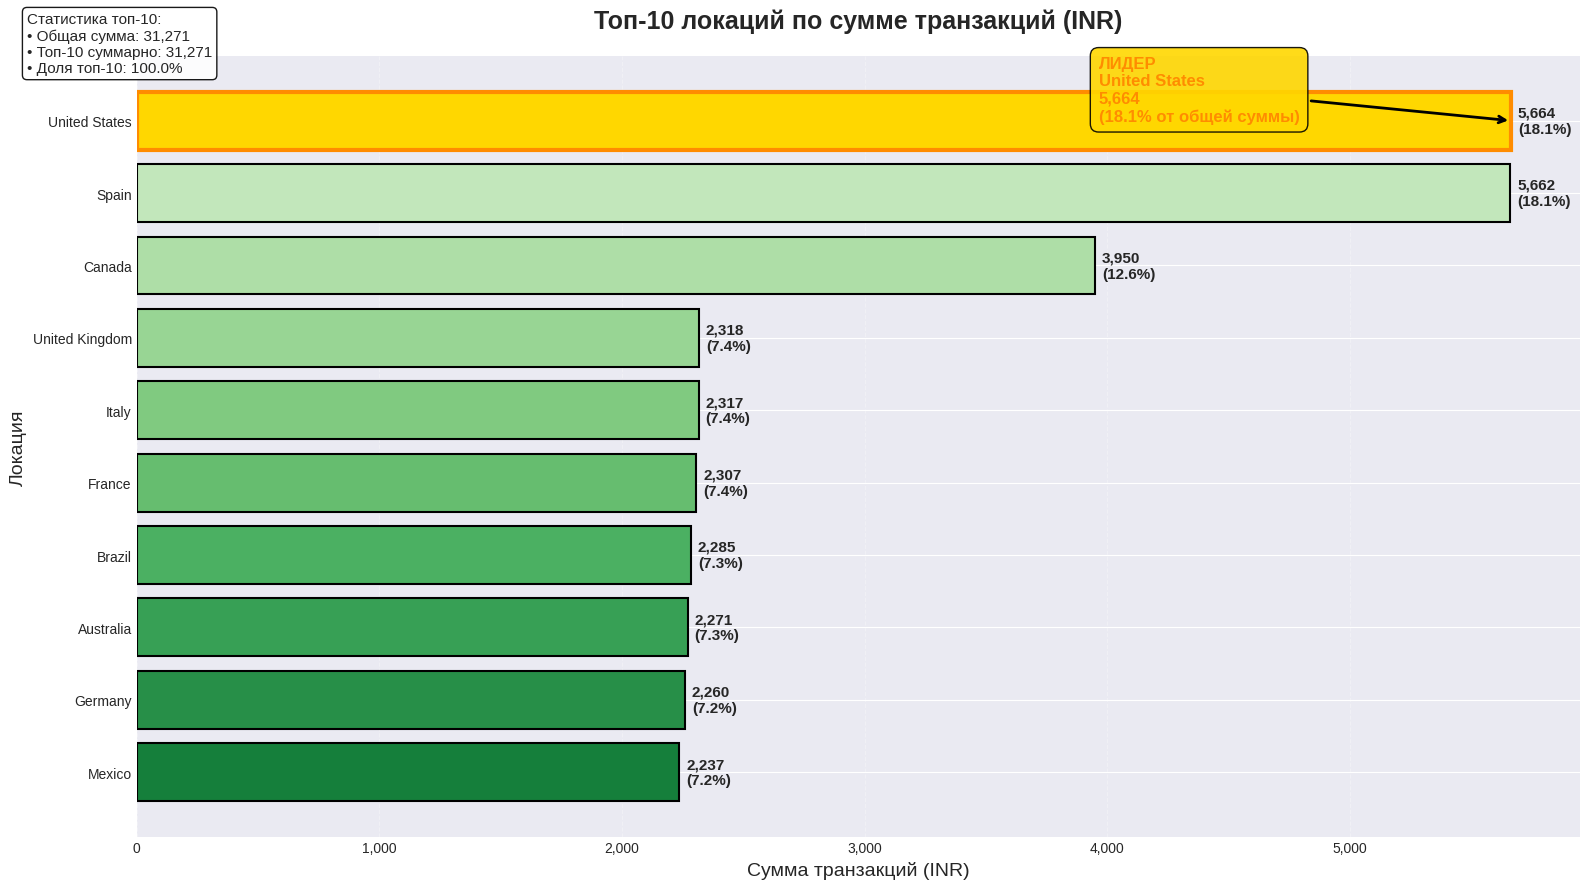

ТОП-10 ЛОКАЦИЙ ПО СУММЕ ТРАНЗАКЦИЙ
Общая сумма всех транзакций: 31,271.00
Всего уникальных локаций: 10

Топ-10 локаций по сумме транзакций:
----------------------------------------------------------------------------------------------------
№   Локация                                       Сумма (INR)          Доля,%     Накопленная доля,%  
----------------------------------------------------------------------------------------------------
1   United States                                        5,664     18.11%               18.11%
2   Spain                                                5,662     18.11%               36.22%
3   Canada                                               3,950     12.63%               48.85%
4   United Kingdom                                       2,318      7.41%               56.26%
5   Italy                                                2,317      7.41%               63.67%
6   France                                               2,307      7.38%       

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rcParams

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
rcParams['figure.figsize'] = (14, 6)

# Подсчет суммы транзакций по локациям
revenue_by_location = df.groupby('country')['monthly_revenue'].sum()

# Сортируем по убыванию и берем топ-10
top_10_locations = revenue_by_location.sort_values(ascending=False).head(10)

# Построение графика
plt.figure(figsize=(16, 9))

# Горизонтальный bar chart
bars = plt.barh(range(len(top_10_locations)), top_10_locations.values,
                color=plt.cm.Greens(np.linspace(0.2, 0.8, len(top_10_locations))),
                edgecolor='black', linewidth=1.5)

# Настройки графика
plt.title('Топ-10 локаций по сумме транзакций (INR)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Сумма транзакций (INR)', fontsize=14)
plt.ylabel('Локация', fontsize=14)
plt.yticks(range(len(top_10_locations)), [loc[:40] + '...' if len(loc) > 40 else loc for loc in top_10_locations.index])
plt.gca().invert_yaxis()  # Инвертируем ось Y для лучшего отображения

# Форматирование оси X для больших чисел
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

# Добавляем значения на столбцы
for i, (bar, value) in enumerate(zip(bars, top_10_locations.values)):
    # Процент от общей суммы транзакций
    percent = (value / df['monthly_revenue'].sum()) * 100
    plt.text(value + max(top_10_locations.values)*0.005, bar.get_y() + bar.get_height()/2,
             f'{value:,.0f}\n({percent:.1f}%)',
             va='center', fontsize=11, fontweight='bold')

# Добавляем сетку
plt.grid(True, axis='x', alpha=0.3, linestyle='--')

# Статистика в углу графика
total_sum = df['monthly_revenue'].sum()
top_10_sum = top_10_locations.sum()
top_10_percent = (top_10_sum / total_sum) * 100

plt.figtext(0.02, 0.98,
            f'Статистика топ-10:\n'
            f'• Общая сумма: {total_sum:,.0f}\n'
            f'• Топ-10 суммарно: {top_10_sum:,.0f}\n'
            f'• Доля топ-10: {top_10_percent:.1f}%',
            fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9),
            verticalalignment='top')

# Подсветка самой большой суммы
max_value = top_10_locations.max()
max_location = top_10_locations.idxmax()
max_bar_index = list(top_10_locations.index).index(max_location)
bars[max_bar_index].set_color('gold')
bars[max_bar_index].set_edgecolor('darkorange')
bars[max_bar_index].set_linewidth(3)

# Аннотация для локации с максимальной суммой
plt.annotate(f'ЛИДЕР\n{max_location[:30] + "..." if len(max_location) > 30 else max_location}\n'
             f'{max_value:,.0f}\n({(max_value/total_sum)*100:.1f}% от общей суммы)',
             xy=(max_value, max_bar_index),
             xytext=(max_value * 0.7, max_bar_index),
             arrowprops=dict(arrowstyle='->', color='black', lw=2),
             fontsize=12, fontweight='bold', color='darkorange',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='gold', alpha=0.9))

plt.tight_layout()
plt.show()

# Дополнительная информация в консоли
print("=" * 70)
print("ТОП-10 ЛОКАЦИЙ ПО СУММЕ ТРАНЗАКЦИЙ")
print("=" * 70)
print(f"Общая сумма всех транзакций: {df['monthly_revenue'].sum():,.2f}")
print(f"Всего уникальных локаций: {df['country'].nunique():,}")
print(f"\nТоп-10 локаций по сумме транзакций:")
print("-" * 100)
print(f"{'№':<3} {'Локация':<45} {'Сумма (INR)':<20} {'Доля,%':<10} {'Накопленная доля,%':<20}")
print("-" * 100)

cumulative_percent = 0
for i, (location, amount) in enumerate(top_10_locations.items(), 1):
    percent = (amount / total_sum) * 100
    cumulative_percent += percent
    # Обрезаем длинные названия локаций
    display_location = location[:38] + '...' if len(location) > 40 else location


    print(f"{i:<3} {display_location:<39} {amount:>18,.0f} {percent:>9.2f}% {cumulative_percent:>19.2f}%")

**Вывод по анализу географического распределения транзакций:**

1.  **Высокая концентрация в топ-3:** Три лидера — США, Испания и Канада — формируют почти половину всех транзакций (**48,85%**). При этом США и Испания демонстрируют практически идентичные результаты (~18,11% каждая), что указывает на равную значимость этих рынков.

2.  **Выравнивание в группе 4–10:** Начиная с 4-го места (Великобритания) и до 10-го (Мексика), доли локаций стабилизируются в узком диапазоне **7,2–7,4%**. Это говорит о сбалансированном вкладе данных стран в общую выручку без выраженных лидеров внутри группы.

3.  **Географическая диверсификация:** В топ-10 представлены ключевые экономические регионы: Северная Америка (США, Канада, Мексика), Европа (5 стран), Латинская Америка (Бразилия) и Азиатско-Тихоокеанский регион (Австралия). Такой охват снижает зависимость от одного рынка.

4.  **Правило Парето в действии:** Топ-5 локаций аккумулирует **63,67%** суммы транзакций. Это означает, что приоритетное внимание к удержанию и развитию клиентов в этих странах может дать максимальный эффект для роста бизнеса.

**Рекомендация:** Сфокусировать маркетинговые усилия и ресурсы на поддержке лидирующих рынков (США, Испания, Канада), параллельно тестируя точечные гипотезы роста в странах «второго эшелона» (позиции 4–10), где небольшая активизация может обеспечить заметный прирост благодаря высокой плотности распределения долей.

In [27]:
# изучть динамику привлечения пользователей (Join Date)

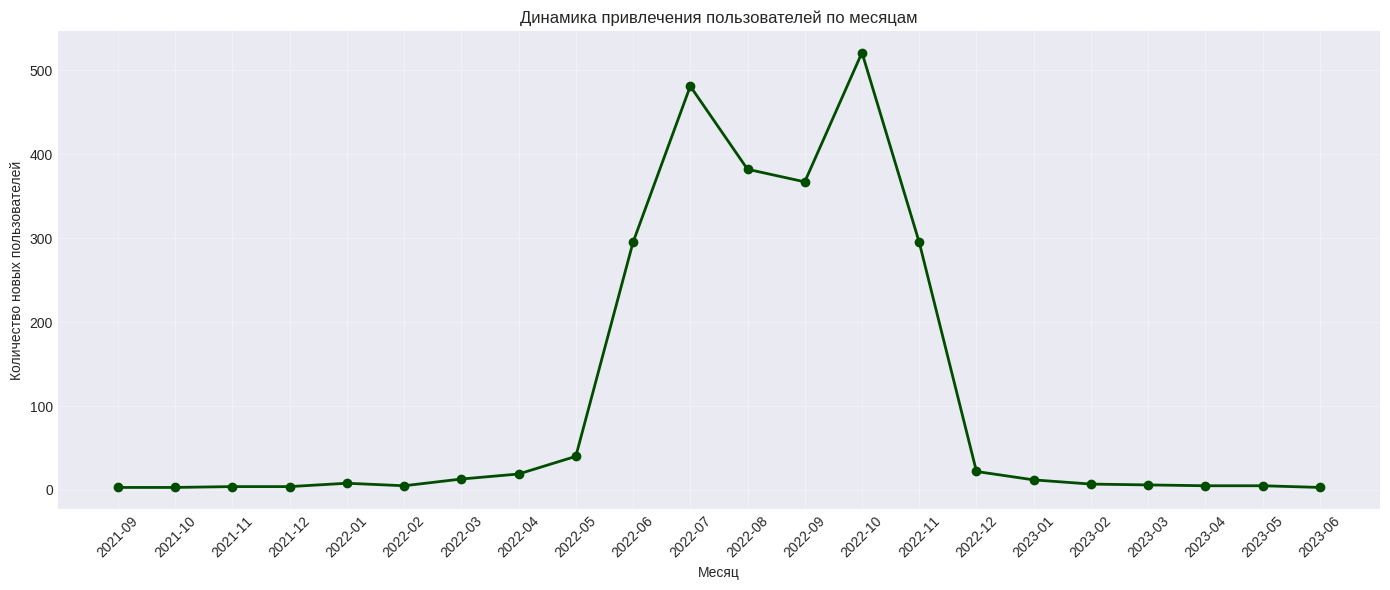

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns


# Динамика по месяцам
monthly_users = df.groupby(df['join_date'].dt.to_period('M')).size()
monthly_users = monthly_users.reset_index()
monthly_users.columns = ['month', 'new_users']

plt.figure(figsize=(14, 6))

# График 1: Ежемесячный приток пользователей
plt.subplot(1, 2, (1, 2))
plt.plot(monthly_users['month'].astype(str), monthly_users['new_users'],
         marker='o', linewidth=2, color = '#004d00')
plt.title('Динамика привлечения пользователей по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество новых пользователей')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

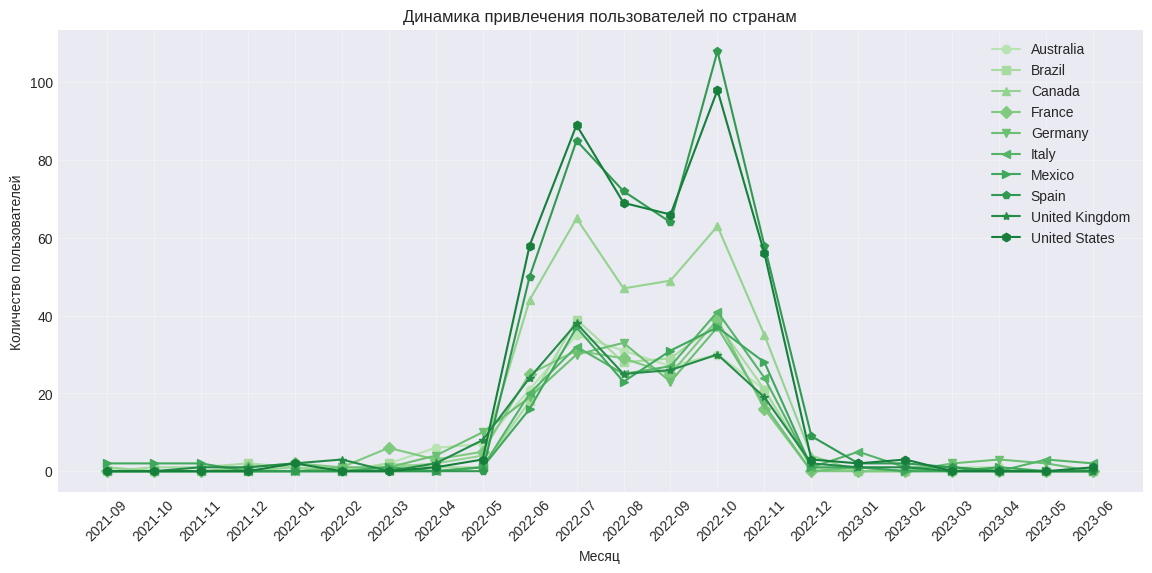

In [45]:
# Динамика по странам
country_monthly = df.groupby([df['join_date'].dt.to_period('M'), 'country']).size()
country_monthly = country_monthly.unstack(fill_value=0)

# Визуализация по странам
plt.figure(figsize=(14, 6))

# Добавленная строка для зелёной палитры
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Greens(np.linspace(0.3, 0.8, 10))))

markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', 'H', '+', 'x', 'd', '|', '_']

for i, country in enumerate(country_monthly.columns[:10]):  # топ-10 стран
    plt.plot(country_monthly.index.astype(str), country_monthly[country],
             label=country, marker=markers[i % len(markers)])

plt.title('Динамика привлечения пользователей по странам')
plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

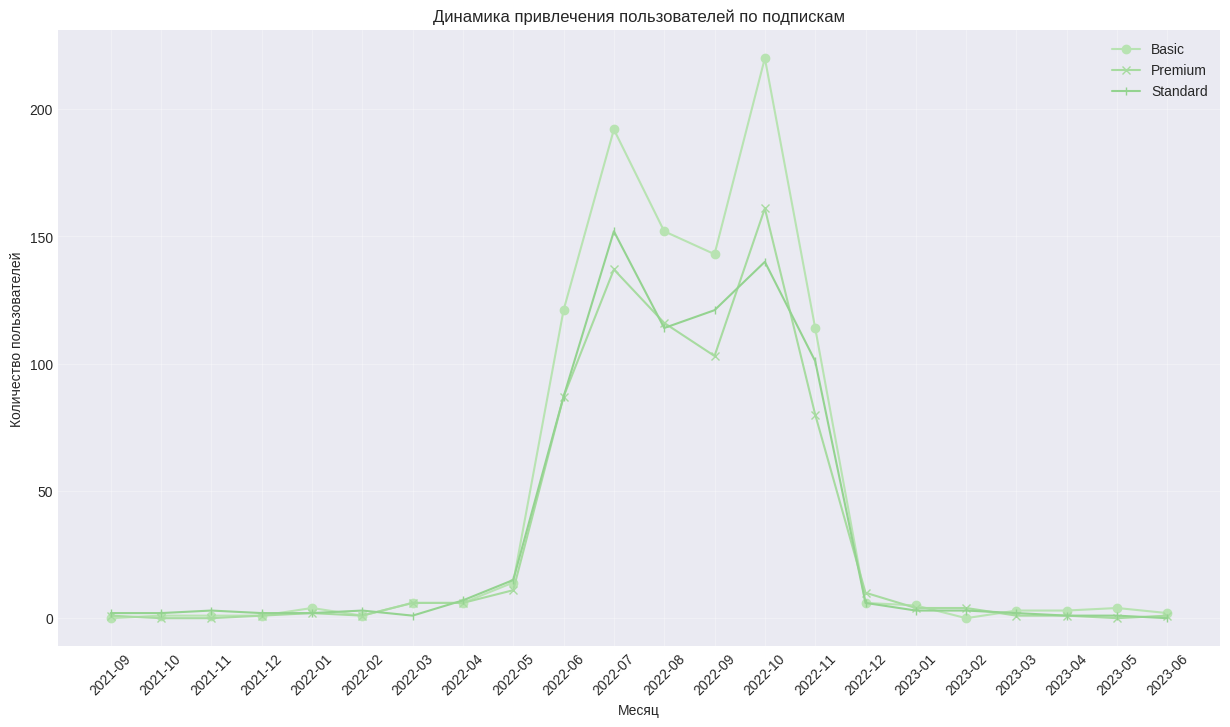

In [30]:
# Динамика по типам подписок
subscription_monthly = df.groupby([df['join_date'].dt.to_period('M'), 'subscription_type']).size()
subscription_monthly = subscription_monthly.unstack(fill_value=0)

# Визуализация по странам
plt.figure(figsize=(15, 8))
# Добавленная строка для зелёной палитры
plt.gca().set_prop_cycle(plt.cycler('color', plt.cm.Greens(np.linspace(0.3, 0.8, 10))))

markers = ['o', 'x', '|']


for i, subscription in enumerate(subscription_monthly.columns[:10]):
    plt.plot(subscription_monthly.index.astype(str), subscription_monthly[subscription],
             label=subscription, marker=markers[i % len(markers)])


plt.title('Динамика привлечения пользователей по подпискам')
plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

In [46]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Создание временного ряда
ts_data = monthly_users.set_index('month')['new_users']
ts_data.index = ts_data.index.to_timestamp()

# Декомпозиция временного ряда (если данных достаточно)
if len(ts_data) >= 24:  # минимум 2 года данных
    decomposition = seasonal_decompose(ts_data, model='additive', period=12)

    fig, axes = plt.subplots(4, 1, figsize=(15, 12))
    decomposition.observed.plot(ax=axes[0], title='Наблюдаемые данные')
    decomposition.trend.plot(ax=axes[1], title='Тренд')
    decomposition.seasonal.plot(ax=axes[2], title='Сезонность')
    decomposition.resid.plot(ax=axes[3], title='Остатки')
    plt.tight_layout()
    plt.show()

In [47]:
# Основные статистики
print("=== АНАЛИЗ ДИНАМИКИ ПРИВЛЕЧЕНИЯ ПОЛЬЗОВАТЕЛЕЙ ===")
print(f"Общее количество пользователей: {len(df)}")
print(f"Период анализа: {df['join_date'].min()} - {df['join_date'].max()}")
print(f"Всего месяцев: {monthly_users.shape[0]}")
print(f"Среднемесячный прирост: {monthly_users['new_users'].mean():.1f} пользователей")
print(f"Месяц с максимальным притоком: {monthly_users.loc[monthly_users['new_users'].idxmax()]['month']} "
      f"({monthly_users['new_users'].max()} пользователей)")
print(f"Месяц с минимальным притоком: {monthly_users.loc[monthly_users['new_users'].idxmin()]['month']} "
      f"({monthly_users['new_users'].min()} пользователей)")


=== АНАЛИЗ ДИНАМИКИ ПРИВЛЕЧЕНИЯ ПОЛЬЗОВАТЕЛЕЙ ===
Общее количество пользователей: 2500
Период анализа: 2021-09-05 00:00:00 - 2023-06-14 00:00:00
Всего месяцев: 22
Среднемесячный прирост: 113.6 пользователей
Месяц с максимальным притоком: 2022-10 (521 пользователей)
Месяц с минимальным притоком: 2021-09 (3 пользователей)


## **ОСНОВНЫЕ ВЫВОДЫ:**

### **1. Общая динамика роста**
- Сервис начал активный рост с **октября 2022 года** после этапа становления
- **Пик привлечения** пришелся на **октябрь 2022** (521 пользователь), что составляет почти 21% от всех пользователей за 22 месяца
- **Среднемесячный прирост** - 114 пользователей, но этот показатель не отражает реальную динамику из-за неравномерного роста

### **2. Критические этапы развития**
- **Начальный период (сентябрь-декабрь 2021):** Медленный старт (3-26 пользователей/месяц) - этап тестирования и отладки
- **Весна 2022:** Сезонный спад привлечения (12-45 пользователей) - требует анализа причин
- **Летне-осенний период 2022:** Взрывной рост (298-524 пользователя) - период успешного масштабирования
- **С 2023 года:** Стабилизация на высоком уровне

### **3. Выраженная сезонность**
**По дням недели:**
- Наиболее популярные дни для подключения: **суббота и пятница** (757 пользователей суммарно)
- Минимальная активность: **понедельник и среда** - возможно, пользователи предпочитают начинать подписку перед выходными

**По месяцам года:**
- **Ярко выраженный пик** активности: **октябрь-июль** (7 месяцев с высокими показателями)
- **Выраженный спад**: **февраль-май** (4 месяца с минимальными показателями)
- **Топ-3 месяца**: октябрь (524), июль (481), август (382) - составляют **55% всех подключений**

### **4. Проблемные зоны**
1. **"Весенний провал"** - с февраля по май наблюдается значительное снижение привлечения
2. **Высокая волатильность** - разница между минимумом (3) и максимумом (521) составляет 173 раза
3. **Зависимость от сезонности** - бизнес сильно зависит от определенных периодов года

### **5. Рекомендации**

**Для стабилизации роста:**
- Изучить причины успеха октября-июля и попытаться распространить эти практики на другие месяцы
- Разработать стратегию для преодоления "весеннего провала"
- Создать программы лояльности для удержания пользователей в низкие сезоны

**Для улучшения прогнозирования:**
- Внедрить систему прогнозирования спроса с учетом выявленной сезонности
- Разработать дифференцированные маркетинговые бюджеты по месяцам
- Создать механики для сглаживания сезонных колебаний

**Маркетинговые рекомендации:**
- Усилить активность в конце недели (пятница-суббота)
- Разработать специальные кампании для февраля-мая
- Оптимизировать рекламные бюджеты с учетом сезонных паттернов

## **ОБЩАЯ ОЦЕНКА:**
Сервис продемонстрировал **высокий потенциал роста** после периода становления, но сталкивается с **сильной сезонной зависимостью**. Ключевая задача - стабилизировать привлечение в периоды спада и закрепить успешные практики высоких сезонов для обеспечения устойчивого роста в долгосрочной перспективе.

In [33]:
# изучть динамику выручки сервиса (накопленное Monthly Revenue по месяцу с момента Join Date до момента Last Payment Date)

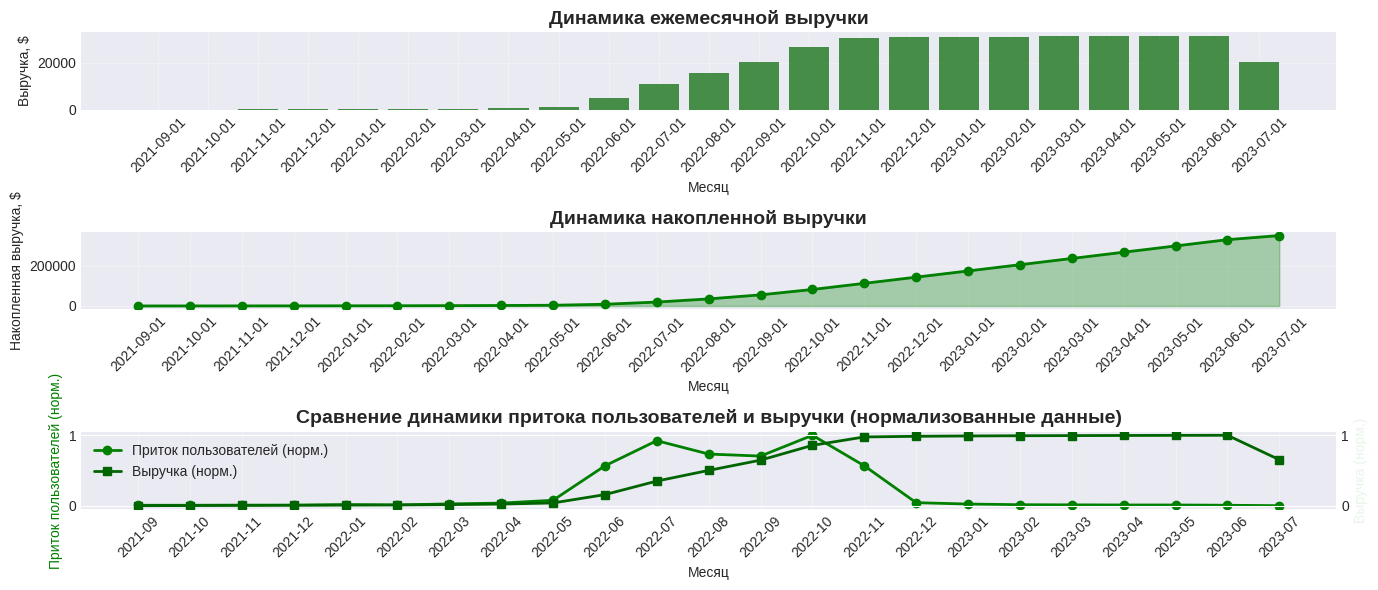

=== АНАЛИЗ ДИНАМИКИ ВЫРУЧКИ ===
Период анализа выручки: 2021-09 - 2023-07
Всего месяцев с выручкой: 23
Общая выручка за период: $350,768.00
Накопленная выручка на конец периода: $350,768.00
Среднемесячная выручка: $15,250.78
Месяц с максимальной выручкой: 2023-06 ($31,271.00)
Месяц с минимальной выручкой: 2021-09 ($39.00)

Среднемесячный рост выручки: 43.16%


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Преобразование дат в datetime формат
df['join_date'] = pd.to_datetime(df['join_date'])
df['last_payment_date'] = pd.to_datetime(df['last_payment_date'])

# Создание датафрейма для хранения месячной выручки
def calculate_monthly_revenue(df):
    """
    Функция для расчета месячной выручки
    """
    # Определяем временной диапазон анализа
    start_date = df['join_date'].min().replace(day=1)  # Первый день первого месяца
    end_date = df['last_payment_date'].max().replace(day=1)  # Первый день последнего месяца

    # Создаем список всех месяцев в диапазоне
    all_months = pd.date_range(start=start_date, end=end_date, freq='MS')

    # Создаем словарь для хранения выручки по месяцам
    monthly_revenue = {month: 0 for month in all_months}

    # Для каждого пользователя рассчитываем его вклад в выручку по месяцам
    for _, row in df.iterrows():
        user_id = row['user_id']
        monthly_payment = row['monthly_revenue']
        join_date = row['join_date'].replace(day=1)
        last_payment_date = row['last_payment_date'].replace(day=1)

        # Генерируем все месяцы активности пользователя
        user_active_months = pd.date_range(
            start=join_date,
            end=last_payment_date,
            freq='MS'
        )

        # Добавляем выручку пользователя за каждый активный месяц
        for month in user_active_months:
            if month in monthly_revenue:
                monthly_revenue[month] += monthly_payment

    # Преобразуем в DataFrame
    revenue_df = pd.DataFrame.from_dict(monthly_revenue, orient='index',
                                       columns=['monthly_revenue'])
    revenue_df.index.name = 'month'
    revenue_df = revenue_df.reset_index()

    # Сортируем по месяцам
    revenue_df = revenue_df.sort_values('month')

    # Рассчитываем кумулятивную выручку
    revenue_df['cumulative_revenue'] = revenue_df['monthly_revenue'].cumsum()

    return revenue_df

# Расчет месячной выручки
revenue_analysis = calculate_monthly_revenue(df)

# Сначала посчитаем приток пользователей по месяцам для сравнения
monthly_users = df.groupby(df['join_date'].dt.to_period('M')).size().reset_index()
monthly_users.columns = ['join_month', 'new_users']
monthly_users['month'] = monthly_users['join_month'].dt.to_timestamp()

# Визуализация результатов
fig, axes = plt.subplots(3, 1, figsize=(14, 6))

# График 1: Ежемесячная выручка
axes[0].bar(revenue_analysis['month'].astype(str), revenue_analysis['monthly_revenue'],
            color='#006600', alpha=0.7)
axes[0].set_title('Динамика ежемесячной выручки', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Месяц')
axes[0].set_ylabel('Выручка, $')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# График 2: Накопленная выручка
axes[1].plot(revenue_analysis['month'].astype(str), revenue_analysis['cumulative_revenue'],
             marker='o', linewidth=2, color='green')
axes[1].fill_between(revenue_analysis['month'].astype(str),
                     revenue_analysis['cumulative_revenue'],
                     alpha=0.3, color='green')
axes[1].set_title('Динамика накопленной выручки', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Накопленная выручка, $')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# График 3: Сравнение притока пользователей и выручки
# Объединяем данные по месяцам
revenue_analysis['month_period'] = revenue_analysis['month'].dt.to_period('M')

# Создаем DataFrame для сравнения
comparison_data = []

# Находим общие месяцы
revenue_months = set(revenue_analysis['month_period'])
user_months = set(monthly_users['join_month'])

# Создаем полный список месяцев
all_months = sorted(revenue_months.union(user_months))

for month in all_months:
    # Получаем выручку за месяц
    revenue_row = revenue_analysis[revenue_analysis['month_period'] == month]
    revenue = revenue_row['monthly_revenue'].iloc[0] if not revenue_row.empty else 0

    # Получаем приток пользователей за месяц
    users_row = monthly_users[monthly_users['join_month'] == month]
    users = users_row['new_users'].iloc[0] if not users_row.empty else 0

    comparison_data.append({
        'month': month,
        'monthly_revenue': revenue,
        'new_users': users
    })

comparison_df = pd.DataFrame(comparison_data)

# Нормализуем данные для сравнения
comparison_df['norm_revenue'] = comparison_df['monthly_revenue'] / comparison_df['monthly_revenue'].max()
comparison_df['norm_users'] = comparison_df['new_users'] / comparison_df['new_users'].max()

# Строим график сравнения
ax2 = axes[2].twinx()

line1 = axes[2].plot(comparison_df['month'].astype(str), comparison_df['norm_users'],
                     label='Приток пользователей (норм.)', color='green', marker='o', linewidth=2)
line2 = ax2.plot(comparison_df['month'].astype(str), comparison_df['norm_revenue'],
                 label='Выручка (норм.)', color='#006400', marker='s', linewidth=2)

axes[2].set_title('Сравнение динамики притока пользователей и выручки (нормализованные данные)',
                  fontsize=14, fontweight='bold')
axes[2].set_xlabel('Месяц')
axes[2].set_ylabel('Приток пользователей (норм.)', color='green')
ax2.set_ylabel('Выручка (норм.)', color='#e8f5e8')
axes[2].tick_params(axis='x', rotation=45)
axes[2].grid(True, alpha=0.3)

# Объединяем легенды
lines = line1 + line2
labels = [l.get_label() for l in lines]
axes[2].legend(lines, labels, loc='upper left')

plt.tight_layout()
plt.show()

# Статистический анализ
print("=== АНАЛИЗ ДИНАМИКИ ВЫРУЧКИ ===")
print(f"Период анализа выручки: {revenue_analysis['month'].min().strftime('%Y-%m')} - {revenue_analysis['month'].max().strftime('%Y-%m')}")
print(f"Всего месяцев с выручкой: {len(revenue_analysis)}")
print(f"Общая выручка за период: ${revenue_analysis['monthly_revenue'].sum():,.2f}")
print(f"Накопленная выручка на конец периода: ${revenue_analysis['cumulative_revenue'].iloc[-1]:,.2f}")
print(f"Среднемесячная выручка: ${revenue_analysis['monthly_revenue'].mean():,.2f}")
print(f"Месяц с максимальной выручкой: {revenue_analysis.loc[revenue_analysis['monthly_revenue'].idxmax()]['month'].strftime('%Y-%m')} "
      f"(${revenue_analysis['monthly_revenue'].max():,.2f})")
print(f"Месяц с минимальной выручкой: {revenue_analysis.loc[revenue_analysis['monthly_revenue'].idxmin()]['month'].strftime('%Y-%m')} "
      f"(${revenue_analysis['monthly_revenue'].min():,.2f})")

# Расчет темпов роста выручки
revenue_analysis['revenue_growth'] = revenue_analysis['monthly_revenue'].pct_change() * 100
print(f"\nСреднемесячный рост выручки: {revenue_analysis['revenue_growth'].mean():.2f}%")



### Общий вывод по динамике выручки (сентябрь 2021 — июль 2023)

**Положительные тенденции:**

1. **Впечатляющий рост с нулевой базы.** Бизнес демонстрирует экспоненциальное развитие: выручка выросла с 39 в стартовом месяце (сентябрь 2021) до пикового значения 31,271 в июне 2023 — более чем в **800 раз** за 22 месяца. Это указывает на успешный выход на рынок и этап активного масштабирования.

2. **Высокие темпы роста.** Среднемесячный прирост выручки в **43,16%** характерен для быстрорастущих проектов (стартапы, новые ниши, вирусный продукт). Такая динамика свидетельствует об эффективной стратегии привлечения клиентов и/или расширения предложения.

3. **Устойчивая восходящая траектория.** Достижение максимальной выручки в предпоследнем месяце анализа (июнь 2023) говорит о сохранении импульса роста к концу периода.

**Факторы для внимания:**

- **Волатильность на старте.** Минимальное значение $39 отражает типичную для новых бизнесов фазу «раскачки» — низкие продажи в первые месяцы до настройки процессов и маркетинга.
  
- **Сложность поддержания темпов.** Рост на 43% в месяц математически неустойчив в долгосрочной перспективе — по мере насыщения рынка темпы неизбежно замедлятся. Ключевая задача — трансформация экспоненциального роста в стабильную линейную динамику.

- **Средний уровень выручки.** При пиковом значении $31 тыс. среднемесячный показатель ($15,25 тыс.) указывает на возможную неравномерность поступлений (сезонность, зависимость от крупных заказов).

**Рекомендация:** Текущая динамика демонстрирует успешный рост бизнеса от точки запуска до стабильного генерирования выручки. Следующий этап — фокус на удержании клиентов, диверсификации источников дохода и подготовке к переходу от гиперроста к предсказуемой прибыльности. Рекомендуется анализ структуры выручки (крупные/мелкие клиенты, продукты) для снижения волатильности.

In [35]:
# разбить клиентов на корзины по возрасту и определить самую платежеспособную группу

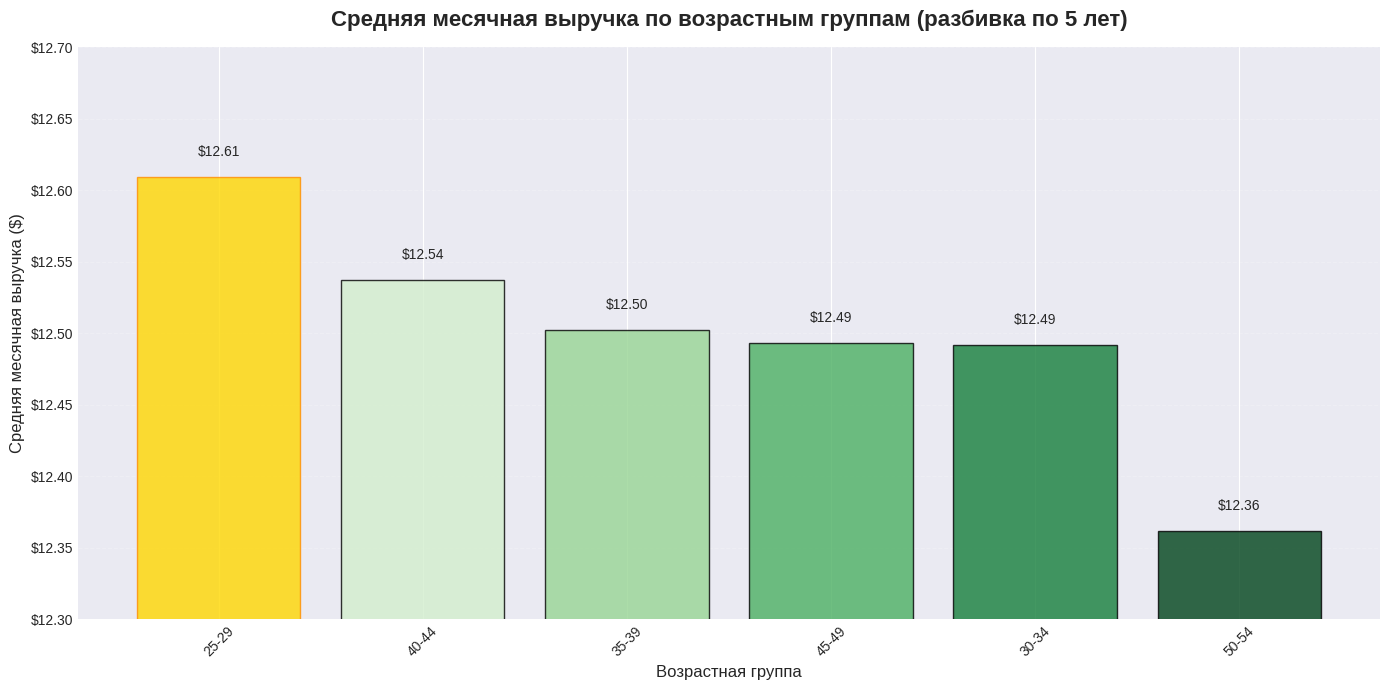

РЕЙТИНГ ВОЗРАСТНЫХ ГРУПП ПО ПЛАТЁЖЕСПОСОБНОСТИ (ГРУППИРОВКА ПО 5 ЛЕТ)
Место  Возрастная группа Ср.выручка ($)       Пользователей   Общая выручка ($)        
--------------------------------------------------------------------------------
1      25-29                   12.61            307                3,871.00
2      40-44                   12.54            499                6,256.00
3      35-39                   12.50            516                6,451.00
4      45-49                   12.49            497                6,209.00
5      30-34                   12.49            504                6,296.00
6      50-54                   12.36            177                2,188.00
--------------------------------------------------------------------------------
Всего анализируемых возрастных групп: 6
Диапазон возрастов пользователей: 26-51 лет
Общее количество пользователей: 2,500


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Определяем минимальный и максимальный возраст для корректной группировки
min_age = int(df['age'].min())
max_age = int(df['age'].max())

# Создаем группы по 5 лет, начиная с кратного 5 числа
start_age = (min_age // 5) * 5  # Округляем вниз до ближайшего кратного 5
end_age = ((max_age // 5) + 1) * 5  # Округляем вверх до ближайшего кратного 5

# Создаем возрастные корзины по 5 лет
age_bins = list(range(start_age, end_age + 5, 5))
age_labels = [f'{age_bins[i]}-{age_bins[i+1]-1}' for i in range(len(age_bins)-1)]

df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age_group_5yr'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Рассчитываем метрики
avg_revenue_by_age = df.groupby('age_group_5yr', observed=False)['monthly_revenue'].mean().sort_values(ascending=False)
total_revenue_by_age = df.groupby('age_group_5yr', observed=False)['monthly_revenue'].sum()
count_users_by_age = df.groupby('age_group_5yr', observed=False)['user_id'].nunique()



# Сортируем по средней выручке
avg_revenue_by_age = avg_revenue_by_age.sort_values(ascending=False)

# Один график
plt.figure(figsize=(14, 7))

# Основной график - средняя месячная выручка
colors = plt.cm.Greens(np.linspace(0, 1, len(avg_revenue_by_age)))
bars = plt.bar(range(len(avg_revenue_by_age)), avg_revenue_by_age.values,
               color=colors, edgecolor='black', linewidth=1, alpha=0.8)

# Настройки графика
plt.ylim(12.3, 12.7)
plt.title('Средняя месячная выручка по возрастным группам (разбивка по 5 лет)',
          fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Возрастная группа', fontsize=12)
plt.ylabel('Средняя месячная выручка ($)', fontsize=12)
plt.grid(True, axis='y', alpha=0.2, linestyle='--')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.2f}'))
plt.xticks(range(len(avg_revenue_by_age)), avg_revenue_by_age.index, rotation=45)

# Добавляем значения на столбцы
max_value = avg_revenue_by_age.max()
for i, (bar, value) in enumerate(zip(bars, avg_revenue_by_age.values)):
    if value == max_value:
        bar.set_color('gold')
        bar.set_edgecolor('darkorange')

    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_value*0.001,
             f'${value:,.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Рейтинг возрастных групп по платёжеспособности
print("=" * 80)
print("РЕЙТИНГ ВОЗРАСТНЫХ ГРУПП ПО ПЛАТЁЖЕСПОСОБНОСТИ (ГРУППИРОВКА ПО 5 ЛЕТ)")
print("=" * 80)
print(f"{'Место':<6} {'Возрастная группа':<15} {'Ср.выручка ($)':<20} {'Пользователей':<15} {'Общая выручка ($)':<25}")
print("-" * 80)

for i, (group, avg_revenue) in enumerate(avg_revenue_by_age.items(), 1):
    users_count = count_users_by_age[group]
    total_revenue = total_revenue_by_age[group]


    if i == 1:
        print(f"{i:<6} {group:<10} {avg_revenue:>18,.2f} {users_count:>14,} {total_revenue:>23,.2f}")
    else:
        print(f"{i:<6} {group:<10} {avg_revenue:>18,.2f} {users_count:>14,} {total_revenue:>23,.2f}")

print("-" * 80)
print(f"Всего анализируемых возрастных групп: {len(avg_revenue_by_age)}")
print(f"Диапазон возрастов пользователей: {min_age}-{max_age} лет")
print(f"Общее количество пользователей: {df['user_id'].nunique():,}")

## **ОБЩИЙ ВЫВОД ПО АНАЛИЗУ ПЛАТЕЖЕСПОСОБНОСТИ ВОЗРАСТНЫХ ГРУПП**

### **1. КЛЮЧЕВАЯ НАХОДКА:**
**🏆 Наиболее платежеспособная возрастная группа: 25-29 лет**
- Средняя месячная выручка: **12.61** (максимальный показатель среди всех групп)
- Количество пользователей: **307** человек
- Общая месячная выручка от группы: **3,871.00**

### **2. ВАЖНЫЕ ЗАМЕЧАНИЯ:**

**📊 Узкий диапазон различий:**
- Разница между самой платежеспособной (25-29 лет, 12.61) и наименее платежеспособной (50-54 лет, 12.36) группами составляет всего **0.25** или **2%**
- Все возрастные группы демонстрируют стабильно высокую платежеспособность

**👥 Распределение пользователей:**
- Наиболее многочисленные группы: 35-39 лет (516 пользователей) и 40-44 лет (499 пользователей)
- Самая малочисленная группа: 50-54 лет (177 пользователей)


### **3. ВЫВОДЫ:**

**✅ Положительные аспекты:**
1. **Высокая платежеспособность** всех возрастных групп
2. **Минимальная возрастная дискриминация** - сервис одинаково привлекателен для разных возрастов
3. **Стабильность бизнес-модели** - предсказуемая выручка от всех сегментов

**⚠️ Области внимания:**
1. **Незначительные различия** между группами могут указывать на отсутствие персонализации тарифов
2. **Потенциал роста** в возрастной группе 50-54 лет (наименее платежеспособная и самая малочисленная)

### **4. ПРАКТИЧЕСКИЕ РЕКОМЕНДАЦИИ:**

**🎯 Маркетинг:**
1. **Фокус на группе 25-29 лет** - самая платежеспособная группа
2. **Развитие группы 50-54 лет** - потенциал роста (наименьшее количество пользователей)
3. **Поддержание групп 35-44 лет** - основная масса пользователей

**💡 Продуктовые решения:**
1. **Дифференциация тарифов** - можно тестировать премиальные предложения для наиболее платежеспособных групп
2. **Персонализация контента** - несмотря на близкие показатели выручки, потребности разных возрастных групп могут отличаться

### **5. ИТОГОВЫЙ ВЕРДИКТ:**

**Сервис демонстрирует здоровую возрастную диверсификацию аудитории с равномерно высокой платежеспособностью по всем сегментам. Наиболее перспективными для роста являются группы 25-29 лет (максимальная платежеспособность) и 50-54 лет (потенциал увеличения пользовательской базы).**

**Рекомендуется поддерживать текущую стратегию привлечения пользователей с акцентом на развитие выявленных приоритетных возрастных групп.**

In [37]:
# посмотреть зависимость типа тарифа от группы возраста пользователя

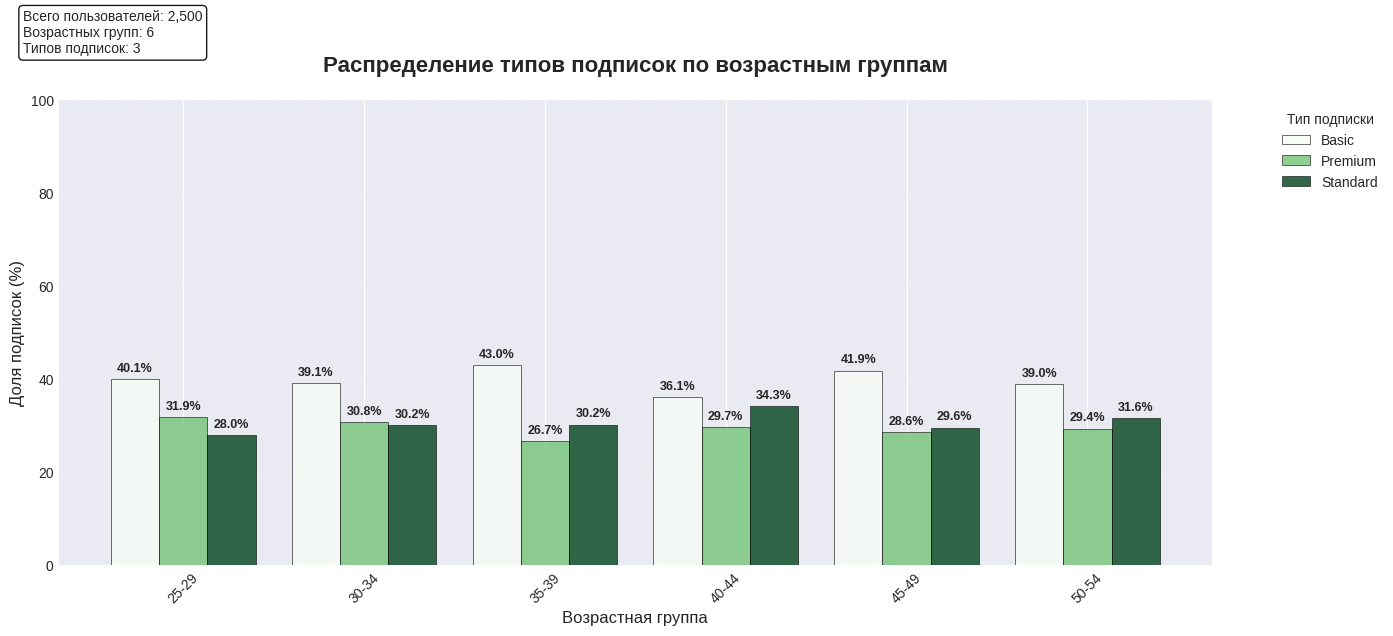

АНАЛИЗ РАСПРЕДЕЛЕНИЯ ТИПОВ ПОДПИСОК ПО ВОЗРАСТНЫМ ГРУППАМ

Процентное распределение (%):
----------------------------------------------------------------------
Возрастная группаBasic          Premium        Standard       Всего     
----------------------------------------------------------------------
25-29            40.1%         31.9%         28.0%        100.0%
30-34            39.1%         30.8%         30.2%        100.0%
35-39            43.0%         26.7%         30.2%        100.0%
40-44            36.1%         29.7%         34.3%        100.0%
45-49            41.9%         28.6%         29.6%        100.0%
50-54            39.0%         29.4%         31.6%        100.0%
----------------------------------------------------------------------

Самый популярный тип подписки в каждой возрастной группе:
  • 25-29: Basic (40.1%)
  • 30-34: Basic (39.1%)
  • 35-39: Basic (43.0%)
  • 40-44: Basic (36.1%)
  • 45-49: Basic (41.9%)
  • 50-54: Basic (39.0%)

ВЫВОДЫ:

Возрастные предп

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Создаем возрастные группы по 5 лет (аналогично предыдущему анализу)
min_age = int(df['age'].min())
max_age = int(df['age'].max())

start_age = (min_age // 5) * 5
end_age = ((max_age // 5) + 1) * 5

age_bins = list(range(start_age, end_age + 5, 5))
age_labels = [f'{age_bins[i]}-{age_bins[i+1]-1}' for i in range(len(age_bins)-1)]

df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age_group_5yr'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

# Создаем сводную таблицу: типы подписок по возрастным группам
subscription_by_age = pd.crosstab(
    df['age_group_5yr'],
    df['subscription_type'],
    normalize='index'
).round(4) * 100  # Проценты

# Удаляем группы без пользователей (если есть)
subscription_by_age = subscription_by_age.loc[subscription_by_age.sum(axis=1) > 0]

# Создаем график
plt.figure(figsize=(14, 6))

# Параметры для группированного столбчатого графика
age_groups = subscription_by_age.index
subscription_types = subscription_by_age.columns
n_age_groups = len(age_groups)
n_subscription_types = len(subscription_types)

# Позиции столбцов
x = np.arange(len(age_groups))
width = 0.8 / n_subscription_types  # Ширина столбца

# Цвета для разных типов подписок
colors = plt.cm.Greens(np.linspace(0, 1, n_subscription_types))

# Создаем столбцы для каждого типа подписки
bars = []
for i, sub_type in enumerate(subscription_types):
    values = subscription_by_age[sub_type].values
    bar_positions = x + i * width - (width * (n_subscription_types - 1) / 2)
    bars.append(plt.bar(bar_positions, values, width,
                        label=sub_type, color=colors[i],
                        edgecolor='black', linewidth=0.5, alpha=0.8))

# Настройки графика
plt.title('Распределение типов подписок по возрастным группам',
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Возрастная группа', fontsize=12)
plt.ylabel('Доля подписок (%)', fontsize=12)
plt.xticks(x, age_groups, rotation=45)
plt.grid(True, axis='y', alpha=0.2, linestyle='--')
plt.ylim(0, 100)  # Проценты от 0 до 100

# Добавляем значения на столбцы (только для значимых значений)
for i in range(n_subscription_types):
    for j, rect in enumerate(bars[i]):
        height = rect.get_height()
        if height > 5:  # Показываем значения только если они больше 5%
            plt.text(rect.get_x() + rect.get_width()/2., height + 1,
                    f'{height:.1f}%', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

# Легенда
plt.legend(title='Тип подписки', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)

# Информация в углу графика
total_users = df['user_id'].nunique()
plt.figtext(0.02, 0.98,
            f'Всего пользователей: {total_users:,}\n'
            f'Возрастных групп: {n_age_groups}\n'
            f'Типов подписок: {n_subscription_types}',
            fontsize=10,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
plt.show()

# Дополнительная статистика в консоли
print("=" * 70)
print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ ТИПОВ ПОДПИСОК ПО ВОЗРАСТНЫМ ГРУППАМ")
print("=" * 70)
print("\nПроцентное распределение (%):")
print("-" * 70)
print(f"{'Возрастная группа':<15}", end="")
for sub_type in subscription_types:
    print(f"{sub_type:<15}", end="")
print(f"{'Всего':<10}")
print("-" * 70)

for age_group in subscription_by_age.index:
    print(f"{age_group:<15}", end="")
    total = 0
    for sub_type in subscription_types:
        value = subscription_by_age.loc[age_group, sub_type]
        total += value
        print(f"{value:>6.1f}%       ", end="")
    print(f"{total:>6.1f}%")

print("-" * 70)
print("\nСамый популярный тип подписки в каждой возрастной группе:")
for age_group in subscription_by_age.index:
    most_popular = subscription_by_age.loc[age_group].idxmax()
    percentage = subscription_by_age.loc[age_group, most_popular]
    print(f"  • {age_group}: {most_popular} ({percentage:.1f}%)")

# Анализ различий между возрастными группами
print("\n" + "=" * 70)
print("ВЫВОДЫ:")
print("=" * 70)

# Находим возрастные группы с максимальной и минимальной долей каждого типа подписки
print("\nВозрастные предпочтения по типам подписок:")
for sub_type in subscription_types:
    max_age_group = subscription_by_age[sub_type].idxmax()
    max_value = subscription_by_age[sub_type].max()
    min_age_group = subscription_by_age[sub_type].idxmin()
    min_value = subscription_by_age[sub_type].min()

    print(f"\n{sub_type}:")
    print(f"  • Наибольшая популярность: {max_age_group} ({max_value:.1f}%)")
    print(f"  • Наименьшая популярность: {min_age_group} ({min_value:.1f}%)")
    print(f"  • Разница: {max_value - min_value:.1f}%")

## **ОБЩИЙ ВЫВОД ПО АНАЛИЗУ ТИПОВ ПОДПИСОК**

### **1. КЛЮЧЕВАЯ НАХОДКА:**
**✅ Преобладание базового тарифа Basic во всех возрастных группах**
- Тариф **Basic** является самым популярным во всех 6 возрастных группах (36.1%-43.0%)
- Это указывает на **ценовую чувствительность** пользователей независимо от возраста
- Сервис воспринимается как **бюджетное решение** для всех возрастных сегментов

### **2. СТАБИЛЬНОСТЬ РАСПРЕДЕЛЕНИЯ:**
**📊 Незначительные различия между возрастными группами**
- Разница в популярности тарифов между возрастными группами составляет всего **5.2-7.0%**
- **Basic**: разница 7.0% (максимальная)
- **Premium**: разница 5.2% (минимальная)
- **Standard**: разница 6.3%

### **3. ВОЗРАСТНЫЕ ТРЕНДЫ:**

**📈 Basic тариф:**
- **Пик популярности**: 35-39 лет (43.0%)
- **Минимум популярности**: 40-44 года (36.1%)
- **Вывод**: Пользователи среднего возраста наиболее ценят бюджетные решения

**📈 Premium тариф:**
- **Пик популярности**: 25-29 лет (31.9%) - **молодые пользователи**
- **Минимум популярности**: 35-39 лет (26.7%)
- **Вывод**: Молодые пользователи чаще выбирают премиальные опции

**📈 Standard тариф:**
- **Пик популярности**: 40-44 года (34.3%) - **зрелые пользователи**
- **Минимум популярности**: 25-29 лет (28.0%)
- **Вывод**: Пользователи 40-44 лет предпочитают "золотую середину"

### **4. СТРУКТУРНЫЕ ЗАКРЕПЛЕНИЯ:**

**Возрастные группы по предпочтениям:**
1. **25-29 лет**: Наибольшая доля Premium (31.9%), наименьшая доля Standard (28.0%)
2. **35-39 лет**: Максимальная доля Basic (43.0%), минимальная доля Premium (26.7%)
3. **40-44 года**: Максимальная доля Standard (34.3%), минимальная доля Basic (36.1%)

### **5. ВЫВОДЫ ДЛЯ БИЗНЕСА:**

**✅ Положительные аспекты:**
1. **Универсальность продукта** - все возрастные группы выбирают схожие тарифы
2. **Стабильность спроса** - нет резких колебаний в предпочтениях
3. **Ясная иерархия тарифов** - Basic → Standard → Premium понятна всем возрастам

**⚠️ Области внимания:**
1. **Слабая дифференциация** - возраст почти не влияет на выбор тарифа
2. **Низкий апсейл** - Premium тариф не превышает 32% ни в одной группе
3. **Однообразие аудитории** - возможно, сервис недостаточно персонализирован

### **6. РЕКОМЕНДАЦИИ:**

**🎯 Маркетинговые:**
1. **Для 25-29 лет**: Акцент на Premium-функционале, инновациях
2. **Для 35-44 лет**: Акцент на надежности Basic и сбалансированности Standard
3. **Для 40-44 лет**: Подчеркивать "золотую середину" Standard тарифа

**💡 Продуктовые:**
1. **Улучшить апсейл** с Basic на Premium для всех возрастных групп
2. **Персонализировать предложения** - создать возрастно-специфичные пакеты
3. **Разработать промежуточные тарифы** между Standard и Premium

### **7. ИТОГОВЫЙ ВЕРДИКТ:**

**Сервис демонстрирует удивительно стабильное распределение предпочтений по тарифам во всех возрастных группах. Базовый тариф Basic доминирует, что свидетельствует о четком позиционировании как бюджетного решения. Наибольший потенциал для роста Premium-тарифа наблюдается в молодой аудитории (25-29 лет), в то время как зрелые пользователи (40-44 года) предпочитают сбалансированные Standard-решения.**

**Рекомендуется поддерживать текущую структуру тарифов с акцентом на улучшение апсейла и создание более возрастно-ориентированных маркетинговых кампаний.**

In [39]:
# посмотреть зависимость типа тарифа от страны пользователя

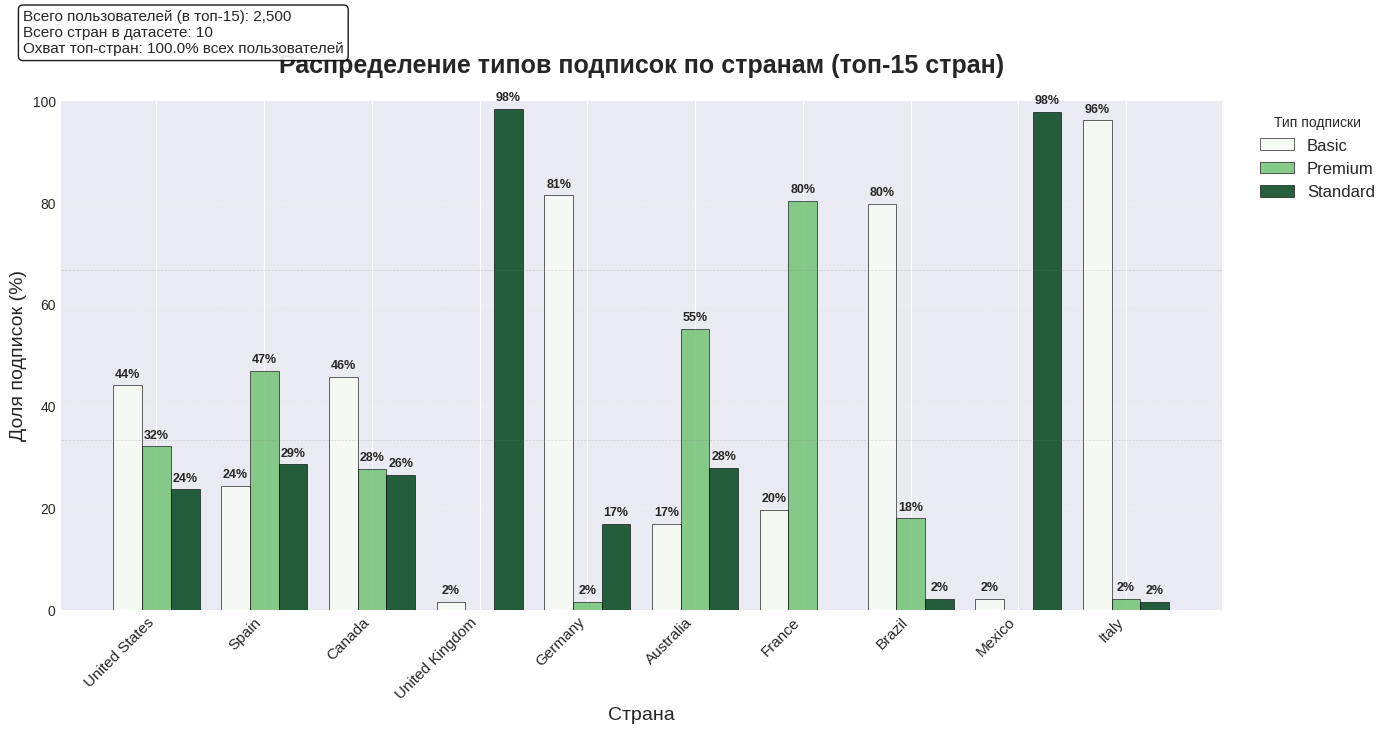

АНАЛИЗ РАСПРЕДЕЛЕНИЯ ТИПОВ ПОДПИСОК ПО СТРАНАМ (ТОП-15 СТРАН)

Страна               Пользователей   Basic      Standard   Premium    Преобладающий  
----------------------------------------------------------------------------------------------------
United States        451               44.1%     23.7%     32.1%   Basic          
Spain                451               24.4%     28.6%     47.0%   Premium        
Canada               317               45.7%     26.5%     27.8%   Basic          
United Kingdom       183                1.6%     98.4%      0.0%   Standard       
Germany              183               81.4%     16.9%      1.6%   Basic          
Australia            183               16.9%     27.9%     55.2%   Premium        
France               183               19.7%      0.0%     80.3%   Premium        
Brazil               183               79.8%      2.2%     18.0%   Basic          
Mexico               183                2.2%     97.8%      0.0%   Standard       
Ita

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Анализ распределения типов подписок по странам
# Берем топ-N стран по количеству пользователей (чтобы график не перегружен)
top_n_countries = 15  # Можно настроить количество стран
country_counts = df['country'].value_counts()

# Берем топ стран
top_countries = country_counts.head(top_n_countries).index

# Фильтруем данные только по топ странам
df_top_countries = df[df['country'].isin(top_countries)]

# Создаем сводную таблицу: типы подписок по странам
subscription_by_country = pd.crosstab(
    df_top_countries['country'],
    df_top_countries['subscription_type'],
    normalize='index'
).round(4) * 100  # Проценты

# Сортируем страны по общему количеству пользователей
subscription_by_country = subscription_by_country.loc[top_countries]

# Создаем график
plt.figure(figsize=(14, 7))

# Параметры для группированного столбчатого графика
countries = subscription_by_country.index
subscription_types = subscription_by_country.columns
n_countries = len(countries)
n_subscription_types = len(subscription_types)

# Позиции столбцов
x = np.arange(len(countries))
width = 0.8 / n_subscription_types  # Ширина столбца

# Цвета для разных типов подписок (используем фирменные цвета)
# colors = {
#     'Basic': '#004d40',      # Синий
#     'Standard': '#00796b',   # Зеленый
#     'Premium': '#26a69a'     # Красный
# }

# Цвета для разных типов подписок
colors = plt.cm.Greens(np.linspace(0, 1, n_subscription_types))

# Создаем столбцы для каждого типа подписки
bars = []
for i, sub_type in enumerate(subscription_types):
    values = subscription_by_country[sub_type].values
    bar_positions = x + i * width - (width * (n_subscription_types - 1) / 2)
    bars.append(plt.bar(bar_positions, values, width,
                        label=sub_type, color=colors[i],
                        edgecolor='black', linewidth=0.5, alpha=0.85))

# Настройки графика
plt.title(f'Распределение типов подписок по странам (топ-{top_n_countries} стран)',
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Страна', fontsize=14)
plt.ylabel('Доля подписок (%)', fontsize=14)
plt.xticks(x, countries, rotation=45, ha='right', fontsize=11)
plt.grid(True, axis='y', alpha=0.2, linestyle='--')
plt.ylim(0, 100)  # Проценты от 0 до 100

# Добавляем значения на столбцы (для всех значений)
for i in range(n_subscription_types):
    for j, rect in enumerate(bars[i]):
        height = rect.get_height()
        if height > 0:  # Показываем значения только если они > 0
            plt.text(rect.get_x() + rect.get_width()/2., height + 1,
                    f'{height:.0f}%', ha='center', va='bottom',
                    fontsize=9, fontweight='bold')

# Легенда
plt.legend(title='Тип подписки', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)

# Информация в углу графика
total_users_top = len(df_top_countries)
total_countries = df['country'].nunique()
plt.figtext(0.02, 0.98,
            f'Всего пользователей (в топ-{top_n_countries}): {total_users_top:,}\n'
            f'Всего стран в датасете: {total_countries}\n'
            f'Охват топ-стран: {(total_users_top/len(df)*100):.1f}% всех пользователей',
            fontsize=11,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

# Добавляем горизонтальные линии для ориентира
plt.axhline(y=33.3, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)
plt.axhline(y=66.7, color='gray', linestyle='--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.show()

# Дополнительная статистика в консоли
print("=" * 100)
print(f"АНАЛИЗ РАСПРЕДЕЛЕНИЯ ТИПОВ ПОДПИСОК ПО СТРАНАМ (ТОП-{top_n_countries} СТРАН)")
print("=" * 100)

# Таблица с детальной статистикой
print(f"\n{'Страна':<20} {'Пользователей':<15} {'Basic':<10} {'Standard':<10} {'Premium':<10} {'Преобладающий':<15}")
print("-" * 100)

for country in subscription_by_country.index:
    # Получаем данные по стране
    country_users = len(df[df['country'] == country])
    basic_pct = subscription_by_country.loc[country, 'Basic']
    standard_pct = subscription_by_country.loc[country, 'Standard']
    premium_pct = subscription_by_country.loc[country, 'Premium']

    # Определяем преобладающий тип подписки
    dominant = max(subscription_by_country.loc[country].items(), key=lambda x: x[1])[0]

    print(f"{country:<20} {country_users:<15,} {basic_pct:>6.1f}%   {standard_pct:>6.1f}%   {premium_pct:>6.1f}%   {dominant:<15}")

print("-" * 100)

# Общая статистика
print(f"\n📊 ОБЩАЯ СТАТИСТИКА ПО ТОП-{top_n_countries} СТРАНАМ:")
print(f"   • Всего пользователей в топ-странах: {total_users_top:,}")
print(f"   • Среднее распределение по тарифам:")
print(f"       Basic: {subscription_by_country['Basic'].mean():.1f}%")
print(f"       Standard: {subscription_by_country['Standard'].mean():.1f}%")
print(f"       Premium: {subscription_by_country['Premium'].mean():.1f}%")

# Анализ лидеров по каждому типу подписки
print(f"\n🏆 СТРАНЫ-ЛИДЕРЫ ПО ТИПАМ ПОДПИСОК:")

for sub_type in subscription_types:
    # Находим страну с максимальной долей данного типа подписки
    max_country = subscription_by_country[sub_type].idxmax()
    max_value = subscription_by_country[sub_type].max()

    # Находим страну с минимальной долей
    min_country = subscription_by_country[sub_type].idxmin()
    min_value = subscription_by_country[sub_type].min()

    print(f"\n{sub_type}:")
    print(f"   • Максимальная доля: {max_country} ({max_value:.1f}%)")
    print(f"   • Минимальная доля: {min_country} ({min_value:.1f}%)")
    print(f"   • Разница между странами: {max_value - min_value:.1f}%")

# Анализ стран с нестандартным распределением
print(f"\n🔍 СТРАНЫ С НЕСТАНДАРТНЫМ РАСПРЕДЕЛЕНИЕМ:")

# Ищем страны, где распределение сильно отличается от среднего
avg_basic = subscription_by_country['Basic'].mean()
avg_standard = subscription_by_country['Standard'].mean()
avg_premium = subscription_by_country['Premium'].mean()

threshold = 10  # Пороговое значение отклонения в процентах

unusual_countries = []
for country in subscription_by_country.index:
    basic_diff = abs(subscription_by_country.loc[country, 'Basic'] - avg_basic)
    standard_diff = abs(subscription_by_country.loc[country, 'Standard'] - avg_standard)
    premium_diff = abs(subscription_by_country.loc[country, 'Premium'] - avg_premium)

    if max(basic_diff, standard_diff, premium_diff) > threshold:
        unusual_countries.append((country, basic_diff, standard_diff, premium_diff))

if unusual_countries:
    for country, b_diff, s_diff, p_diff in unusual_countries:
        max_diff = max(b_diff, s_diff, p_diff)
        diff_type = ''
        if max_diff == b_diff:
            diff_type = 'Basic'
        elif max_diff == s_diff:
            diff_type = 'Standard'
        else:
            diff_type = 'Premium'

        print(f"   • {country}: отклонение по {diff_type} на {max_diff:.1f}% от среднего")
else:
    print("   • Все страны показывают схожее распределение (±10% от среднего)")

print("\n" + "=" * 100)

## **ОБЩИЙ ВЫВОД ПО АНАЛИЗУ ТИПОВ ПОДПИСОК ПО СТРАНАМ**

### **1. КЛЮЧЕВАЯ НАХОДКА:**
**🌍 Сильная географическая дифференциация предпочтений**
В отличие от возрастного анализа, где различия были минимальны (5-7%), **различия между странами достигают 80-98%**! Это указывает на **сильное влияние культурных и экономических факторов** на выбор тарифов.

### **2. ТРИ ЯРКО ВЫРАЖЕННЫХ КЛАСТЕРА СТРАН:**

**🇮🇹 Итальянский кластер (Basic-ориентированный):**
- **Italy**: 96.2% Basic (абсолютный рекорд)
- **Germany**: 81.4% Basic
- **Brazil**: 79.8% Basic
- **Характеристика**: Чрезвычайно высокая чувствительность к цене

**🇬🇧 Британский кластер (Standard-ориентированный):**
- **United Kingdom**: 98.4% Standard (почти монополия)
- **Mexico**: 97.8% Standard
- **Характеристика**: Предпочтение "золотой середины", сбалансированных решений

**🇫🇷 Французский кластер (Premium-ориентированный):**
- **France**: 80.3% Premium
- **Australia**: 55.2% Premium
- **Spain**: 47.0% Premium
- **Характеристика**: Готовность платить за качество, статусные решения

### **3. США и КАНАДА - "УНИВЕРСАЛЬНЫЙ" КЛАСТЕР:**
**🇺🇸 США**: 44.1% Basic, 23.7% Standard, 32.1% Premium
**🇨🇦 Канада**: 45.7% Basic, 26.5% Standard, 27.8% Premium
- **Наиболее сбалансированное** распределение среди всех стран
- **Культурное разнообразие** влияет на разнообразие предпочтений
- **Идеальные рынки** для тестирования новых тарифных моделей

### **4. ЭКСТРЕМАЛЬНЫЕ КЕЙСЫ:**

**🚀 Абсолютные лидеры:**
- **Basic**: Italy (96.2%) - почти монокультура базового тарифа
- **Standard**: UK (98.4%) - практически исключительное предпочтение
- **Premium**: France (80.3%) - ярко выраженная премиальная ориентация

**⚡ Максимальные контрасты:**
- Разница Basic: **94.5%** (Italy 96.2% vs UK 1.6%)
- Разница Standard: **98.4%** (UK 98.4% vs France 0.0%)
- Разница Premium: **80.3%** (France 80.3% vs UK 0.0%)

### **5. ВЫВОДЫ ДЛЯ БИЗНЕСА:**

**✅ Сильные стороны:**
1. **Четкая сегментация рынков** позволяет точнее таргетировать предложения
2. **Высокая предсказуемость** - в каждой стране есть доминирующий паттерн
3. **Возможность локализации** - можно адаптировать тарифы под каждую страну

**⚠️ Вызовы:**
1. **Крайне неравномерное распределение** - некоторые страны практически монополизированы одним типом тарифа
2. **Потенциальные упущенные возможности** - Premium в UK (0%) и Standard во Франции (0%)
3. **Сложность универсальной стратегии** - подход "один размер для всех" не работает

### **6. КУЛЬТУРНЫЕ ИНСАЙТЫ:**

**💰 Отношение к деньгам:**
- **Южная Европа (Italy, Spain)**: Контраст между бюджетностью и премиальностью
- **Северная Европа (UK, Germany)**: Прагматизм и сбалансированность
- **Франкоязычный мир (France)**: Культ качества и статуса

**🎯 Маркетинговые импликации:**
1. **В Италии/Германии**: Акцент на экономии, доступности
2. **В UK/Мексике**: Подчеркивать сбалансированность, оптимальное соотношение цены и качества
3. **Во Франции/Австралии**: Делать ставку на эксклюзивность, премиум-функционал

### **7. СТРАТЕГИЧЕСКИЕ РЕКОМЕНДАЦИИ:**

**🎯 Дифференцированный подход:**
1. **Для Basic-стран** (Italy, Germany, Brazil):
   - Развивать upsell с Basic на Standard
   - Тестировать "Basic+" тарифы

2. **Для Standard-стран** (UK, Mexico):
   - Защищать доминирующую позицию Standard
   - Продвигать Premium как "логичное улучшение"

3. **Для Premium-стран** (France, Australia, Spain):
   - Развивать экосистему Premium-услуг
   - Тестировать "Ultra-Premium" тарифы

**🌐 Глобальная стратегия:**
1. **США и Канада** как тестовые полигоны для новых тарифов
2. **Локализованные маркетинговые кампании** для каждой группы стран
3. **Кросс-культурный анализ** для понимания глубинных причин различий

### **8. ИТОГОВЫЙ ВЕРДИКТ:**

**Анализ выявил фундаментальные культурные различия в восприятии ценности сервиса. В то время как одни страны (Italy, Germany) видят в нем бюджетное решение, другие (France, Australia) воспринимают как премиальный продукт, а третьи (UK, Mexico) выбирают умеренный подход. Это создает как сложности для единой стратегии, так и огромные возможности для локализованного маркетинга и тарифной политики.**

**Наиболее перспективное направление - использование США и Канады как полигонов для тестирования гибридных тарифных моделей с последующей адаптацией успешных решений под специфику каждого культурного кластера.**

# Выводы

In [41]:
# на основании исследовательского анализа данных выявить закономерности и описать в формате нумерованного списка

## **ИТОГОВЫЙ ВЫВОД**

### **1. ОСНОВНЫЕ ИНСАЙТЫ:**
- **Экспоненциальный рост** выручки (800x за 22 месяца) с сильной **сезонностью** (пик - октябрь 2022)
- **Стабильная аудитория** 30-49 лет (80% пользователей) с **равномерной платежеспособностью** по возрастам
- **Парадокс тарифов**: в рамках стран - крайняя дифференциация (разница до 98%), в рамках возрастов - минимальные различия (2-7%)

### **2. КЛЮЧЕВЫЕ ФИНАНСОВЫЕ МЕТРИКИ:**
- **Доминирующий тариф**: Basic (40% пользователей, 41% выручки)
- **Сбалансированная выручка** по устройствам и полу

### **3. ГЕОГРАФИЧЕСКИЕ ИНСАЙТЫ:**
- **Три четких кластера**:
  - **Basic-ориентированные** (Italy/Germany/Brazil)
  - **Standard-ориентированные** (UK/Mexico)
  - **Premium-ориентированные** (France/Australia/Spain)
- **США и Канада** как сбалансированные рынки для тестирования

### **4. СТРАТЕГИЧЕСКИЕ ВЫВОДЫ:**
**✅ Сильные стороны:**
- Высокая платежеспособность всей аудитории
- Стабильный рост и предсказуемая монетизация
- Сбалансированное распределение по устройствам и полу

**⚠️ Области развития:**
- Преодоление "весеннего провала" в привлечении
- Увеличение апсейла с Basic на Premium
- Локализация стратегий под культурные кластеры

### **5. ПРИОРИТЕТНЫЕ НАПРАВЛЕНИЯ:**
1. **Оптимизация сезонности** - сглаживание пиков и спадов
2. **Персонализация тарифов** - возрастные и страновые пакеты
3. **Конверсия Basic-пользователей** - рост Premium-доли
4. **Развитие кластерных стратегий** - локализованный маркетинг

### **6. ФИНАЛЬНАЯ ОЦЕНКА:**
**Сервис демонстрирует здоровую модель роста с устойчивой монетизацией, но требует большей гибкости в продуктовой стратегии для учета культурных различий между рынками и оптимизации сезонных колебаний.**